# Photon counting with a lossy machine: pulse schedules, the confusion matrix, and how to invert it

The companion notebook `jc_cooling_counting.ipynb` shows the noiseless protocol. One **round** is

1. a resonant Jaynes-Cummings pulse, $H = g(\sigma_+ a + \sigma_- a^\dagger)$, of some duration $t$,
2. measure the qubit,
3. if the outcome was $\lvert e\rangle$, a $\pi$ pulse puts it back in $\lvert g\rangle$.

Every $\lvert e\rangle$ outcome removes exactly one photon, so the number of $\lvert e\rangle$ outcomes
in a run -- the **click count** $C$ -- is a photon-number readout. In the ideal machine, with the right
pulse schedule, $C = n$ with probability 1.

Two separate things break that equality, and this notebook keeps them apart:

**The schedule.** Which pulse length to use in which round is a design choice. Only one schedule walks
the ladder down exactly. Section 4 builds three and compares them.

**Loss.** A photon can leak out of the cavity before the sweep reaches it, and the qubit can relax
during the readout window while it is holding a photon. Both destroy a photon *without* producing a
click, so the counter systematically undercounts.

Both failures are captured by the same object, the **confusion matrix**
$M_{cn} = P(C=c \mid n \text{ photons in})$, and both are undone the same way, by inverting it. The
plan:

| step | what it does |
|------|--------------|
| 1 | write down the coherence times, the gate times, and the Lindblad operators |
| 2 | build three pulse schedules: exact ladder descent, reversed, and fixed pulse length |
| 3 | compute the **exact** click distribution of any input state -- no Monte Carlo |
| 4 | build $M$ for each schedule, with *ideal* Fock prep and with Fock states *climbed up the ladder* under the same decoherence |
| 5 | measure an unknown state, apply $M^{-1}$, and compare to the truth |

Two punchlines. Unfolding with the matrix that actually generated the data is exact to machine
precision -- even for a schedule so badly chosen that it does not cool the cavity at all. And unfolding
with the ladder-prep matrix **over-corrects**, because that matrix has blamed the detector for errors
the *state preparation* committed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import expm
from scipy.optimize import nnls

from qutip import basis, destroy, qeye, tensor, coherent, ket2dm, liouvillian, mesolve, Qobj

## Notation

Every symbol used below, with its code name. Times are in microseconds, rates in $\mu s^{-1}$,
frequencies in MHz.

| symbol | code | meaning |
|---|---|---|
| $N$ | `N_CAV` | cavity Fock truncation; states $\lvert 0\rangle \dots \lvert N-1\rangle$ |
| $R$ | `R` | levels in one full sweep of the ladder, $= N-1$ |
| $C_{\max}$ | `C_MAX` | largest click count tracked, $= N-1$ |
| $P$ | `N_PASSES` | number of sweeps a repeated schedule makes |
| $D$ | `D` | dimension of the joint qubit+cavity space, $= 2N$ |
| $g/2\pi$ | `G_OVER_2PI` | Jaynes-Cummings coupling, MHz |
| $g$ | `G` | the same coupling as an angular rate, $= 2\pi \times$ `G_OVER_2PI` |
| $t_f$ | `swap_time(f)` | duration of a full swap on level $f$, $= \pi/2g\sqrt f$ |
| $t^{(r)}$ | `SCHEDULES[name][r]` | pulse duration used in round $r$ |
| $L_{\rm fix}$ | `FIXED_LEVEL` | the level the fixed-length schedule is tuned to |
| $T_1^{q}$ | `T1_Q` | qubit energy relaxation time |
| $T_2^{q}$ | `T2_Q` | qubit total coherence time |
| $T_\phi^{q}$ | -- | qubit *pure* dephasing time, derived from $T_1^q, T_2^q$ |
| $T_1^{c}$ | `T1_CAV` | cavity single-photon lifetime |
| $T_\phi^{c}$ | `TPHI_CAV` | cavity pure dephasing time |
| $t_\pi$ | `T_PI` | duration of the qubit $\pi$ pulse |
| $t_m$ | `T_MEAS` | duration of the qubit readout window |
| $\gamma_1$ | `gamma_1` | qubit relaxation rate, $1/T_1^q$ |
| $\gamma_\phi$ | `gamma_phi` | qubit pure dephasing rate, $1/T_\phi^q$ |
| $\kappa$ | `kappa` | cavity photon loss rate, $1/T_1^c$ |
| $\kappa_\phi$ | `kappa_phi` | cavity pure dephasing rate, $1/T_\phi^c$ |
| $L_k$ | `c_ops` | Lindblad collapse operators |
| $\mathcal{L}$ | `L_drive`, `L_idle` | Liouvillian, drive on / drive off |
| $S$ | `props[...]` | superoperator propagator, $e^{\mathcal{L}t}$ |
| $\rho_c$ | `branch[c]` | unnormalised state of the runs that have clicked $c$ times |
| $M_{cn}$ | `M_ideal_prep`, `M_climb_prep` | confusion matrix |
| $p_n$ | `p_true` | true photon-number distribution of the input state |
| $q_c$ | `p_meas` | measured click distribution |
| $\hat p_n$ | `p_unfolded` | unfolded estimate, $M^{-1}q$ |

## 1. Parameters

Two kinds of number live here and they are kept apart on purpose.

**Structural** values (`N_CAV`, `R`, `D`, `FIXED_LEVEL`) are sizes and indices; they cannot be zero.

**Physical** values are all collected in `par()`, and *every one of them defaults to zero*, with the
reading: a coherence time of zero means "channel switched off" (infinitely long, rate $0$), and a gate
duration of zero means "instantaneous", so no decoherence accumulates during it. Consequently `par()`
called with no arguments is the perfectly ideal machine, and every nonzero number that enters a result
has to be written out at the call site.

In [2]:
# ---- structural: sizes and indices, may be nonzero ----
N_CAV = 14          # cavity Fock truncation: |0>, |1>, ..., |13>
R = N_CAV - 1       # levels in one full sweep of the ladder
C_MAX = N_CAV - 1   # largest click count we track; the cavity holds at most N-1 photons
D = 2 * N_CAV       # dimension of the joint qubit-cavity Hilbert space
FIXED_LEVEL = 9     # the fixed-length schedule uses a full swap on this level, every round
N_PASSES = 3        # the repeated schedules run their sweep this many times

# ---- the device: named constants, all times in microseconds ----
G_OVER_2PI = 1.0             # Jaynes-Cummings coupling g/2pi                     [MHz]
G = 2 * np.pi * G_OVER_2PI   # ... the same coupling as an angular rate      [rad/us]

T1_Q     = 20000.0    # qubit energy relaxation time
T2_Q     = 80.0     # qubit total coherence time
T1_CAV   = 300.0    # cavity single-photon lifetime
TPHI_CAV = 800.0    # cavity pure dephasing time
T_PI     = 0.15     # duration of the qubit pi pulse
T_MEAS   = 1.10     # duration of the qubit readout window


def par(t1_q=0.0, t2_q=0.0, t1_cav=0.0, tphi_cav=0.0, t_pi=0.0, t_meas=0.0):
    '''Bundle of physical parameters; every one defaults to zero.

    A coherence time of 0.0 means the channel is off (rate 0, not rate infinity).
    A gate duration of 0.0 means the gate is instantaneous.
    So par() with no arguments is the ideal, lossless, infinitely fast machine.
    '''
    return {"t1_q": t1_q, "t2_q": t2_q, "t1_cav": t1_cav, "tphi_cav": tphi_cav,
            "t_pi": t_pi, "t_meas": t_meas}


IDEAL = par()
DEVICE = par(t1_q=T1_Q, t2_q=T2_Q, t1_cav=T1_CAV, tphi_cav=TPHI_CAV,
             t_pi=T_PI, t_meas=T_MEAS)

## 2. Operators

Tensor products are always ordered `tensor(qubit_operator, cavity_operator)`. QuTiP's built-in
`sigmap()` treats `basis(2, 0)` as the excited state, which is easy to trip over, so the qubit
operators are written out by hand.

$$ H \;=\; g\,\bigl(\sigma_+ a + \sigma_- a^\dagger\bigr) $$

In [3]:
# ---- qubit ----
ket_g = basis(2, 0)                  # ground state
ket_e = basis(2, 1)                  # excited state
sigma_plus  = ket_e * ket_g.dag()    # |e><g|, raises the qubit
sigma_minus = ket_g * ket_e.dag()    # |g><e|, lowers the qubit
proj_e_q    = ket_e * ket_e.dag()    # |e><e|, the qubit dephasing operator

# ---- cavity ----
a = destroy(N_CAV)

# ---- identities ----
I_q = qeye(2)
I_c = qeye(N_CAV)

# Resonant Jaynes-Cummings Hamiltonian in the rotating frame:  H = g (sigma_+ a + sigma_- a^dag)
H = G * (tensor(sigma_plus, a) + tensor(sigma_minus, a.dag()))

# Measurement projectors and the pi pulse, as plain numpy matrices: the branch bookkeeping
# below is all numpy, so we convert once here rather than inside the inner loop.
P_g = tensor(ket_g * ket_g.dag(), I_c).full()        # project the qubit onto |g>
P_e = tensor(ket_e * ket_e.dag(), I_c).full()        # project the qubit onto |e>
X_pi = tensor(sigma_plus + sigma_minus, I_c).full()  # pi pulse, qubit only: |e> <-> |g>

n_joint = tensor(I_q, a.dag() * a).full()            # photon number on the joint space

## 3. Decoherence

The state obeys the Lindblad master equation

$$ \dot\rho \;=\; \mathcal{L}\rho \;=\; -i[H,\rho] \;+\; \sum_k \Bigl( L_k \rho L_k^\dagger - \tfrac12\{L_k^\dagger L_k,\, \rho\}\Bigr) $$

with four collapse operators:

$$ L_1 = \sqrt{\gamma_1}\,\sigma_-,\qquad
   L_2 = \sqrt{2\gamma_\phi}\,\lvert e\rangle\langle e\rvert,\qquad
   L_3 = \sqrt{\kappa}\,a,\qquad
   L_4 = \sqrt{2\kappa_\phi}\,a^\dagger a $$

The rates come from the measured times, with the qubit pure-dephasing rate backed out of $T_1$ and
$T_2$ in the usual way:

$$ \gamma_1 = \frac{1}{T_1^q}, \qquad
   \gamma_\phi = \frac{1}{T_\phi^q} = \frac{1}{T_2^q} - \frac{1}{2T_1^q}, \qquad
   \kappa = \frac{1}{T_1^c}, \qquad
   \kappa_\phi = \frac{1}{T_\phi^c} $$

In [4]:
def rate(time_constant):
    '''1/T, with the convention that T = 0 means "this channel is switched off".'''
    if time_constant == 0.0:
        return 0.0
    return 1.0 / time_constant


def collapse_ops(p):
    '''The four Lindblad operators L_k for a parameter set p.'''
    gamma_1 = rate(p["t1_q"])                        # gamma_1   = 1 / T1_q
    gamma_phi = rate(p["t2_q"]) - 0.5 * gamma_1      # 1/Tphi    = 1/T2 - 1/(2 T1)
    kappa = rate(p["t1_cav"])                        # kappa     = 1 / T1_cav
    kappa_phi = rate(p["tphi_cav"])                  # kappa_phi = 1 / Tphi_cav

    if gamma_phi < 0.0:
        raise ValueError("T2 > 2*T1 is unphysical: it implies a negative dephasing rate")

    c_ops = []
    c_ops.append(np.sqrt(gamma_1) * tensor(sigma_minus, I_c))          # L1: qubit relaxation
    c_ops.append(np.sqrt(2 * gamma_phi) * tensor(proj_e_q, I_c))       # L2: qubit dephasing
    c_ops.append(np.sqrt(kappa) * tensor(I_q, a))                      # L3: cavity photon loss
    c_ops.append(np.sqrt(2 * kappa_phi) * tensor(I_q, a.dag() * a))    # L4: cavity dephasing
    return c_ops


print("qubit :  T1 = %6.1f us   T2 = %6.1f us   Tphi = %6.1f us"
      % (T1_Q, T2_Q, 1.0 / (rate(T2_Q) - 0.5 * rate(T1_Q))))
print("cavity:  T1 = %6.1f us                   Tphi = %6.1f us" % (T1_CAV, TPHI_CAV))

qubit :  T1 = 20000.0 us   T2 =   80.0 us   Tphi =   80.2 us
cavity:  T1 =  300.0 us                   Tphi =  800.0 us


## 4. Pulse schedules

Inside the two-state subspace $\{\lvert g,f\rangle,\ \lvert e,f-1\rangle\}$ the Hamiltonian reduces to
$g\sqrt{f}\,\sigma_x$, so a pulse of duration $t$ transfers $\lvert g,f\rangle \to \lvert e,f-1\rangle$
with probability

$$ P_{\rm swap}(f, t) \;=\; \sin^2\!\bigl(g\sqrt{f}\,t\bigr), \qquad\text{full swap at}\qquad
   t_f \;=\; \frac{\pi}{2 g \sqrt{f}} $$

The $\sqrt f$ is the whole story: **there is no single pulse length that swaps every level**, so a
schedule has to choose. Three choices:

**(a) `descending` -- the exact ladder descent.** Round $r$ uses $t_f$ with $f = R, R-1, \dots, 1$.
Because $t_f \propto 1/\sqrt f$, this means *short pulses first, getting longer*, ending on the longest
one $t_1 = \pi/2g$. It is the only schedule that empties the cavity **exactly**, and it does so in
exactly $R$ rounds: a state with support up to $R$ has its top level fully swapped down by round 1,
the new top level by round 2, and so on. You cannot do better, since each round removes at most one
photon.

**(b) `fixed` -- every round the same length,** $t_{L}$ with $L=$ `FIXED_LEVEL`. The simplest thing to
build in hardware. Level $n$ is then swapped with probability $\sin^2\!\bigl(\tfrac\pi2\sqrt{n/L}\bigr)$,
which is 1 only at $n=L$ and **exactly zero** whenever $\sqrt{n/L}$ is an even integer. With
`FIXED_LEVEL = 1` that zero lands on $n=4$, which makes $\lvert 4\rangle$ perfectly invisible and the
confusion matrix exactly singular -- worth trying, but the default `FIXED_LEVEL = 3` keeps the first
zero ($n=12$) outside the truncation.

**More rounds.** Nothing forces a schedule to stop after $R$ rounds. The fixed schedule fails to cool
because it ran out of rounds, not because it cannot make progress, so we also run:

- **`descending x3`** -- the exact sweep, then *started again from the top*, three times over. In the
  ideal machine this buys exactly nothing, because one pass already empties the cavity. On a real
  device it buys a little: a swap damped by dephasing can leave population on a level the descending
  front has already gone past, and only a fresh pass can come back for it.
- **`fixed x3`** -- the same fixed pulse for $3R$ rounds. This one should improve a lot. Every round
  has a decent chance of knocking any level down a rung, so the failure of the fixed schedule really
  is impatience, and rounds are the cure.

Both cost real time, and time is what loss feeds on. Whether more rounds help is therefore a genuine
competition, not a foregone conclusion, and the tables below settle it.

**One bookkeeping consequence.** With more rounds than $R$, a run could click more than $C_{\max}=N-1$
times, which the cavity cannot justify. We track click counts $0 \dots C_{\max}$ only, so every
confusion matrix stays square; probability that wanted to click past that is dropped and shows up as a
*deficit* in the column sums, which the checks print. Exceeding $C_{\max}$ requires overcounting, which
only the $\pi$-pulse channel of section 7 permits, so a single pass leaks $\sim 10^{-15}$ while the
three-pass schedules -- three times the $\pi$ pulses -- leak $\sim 6\times10^{-3}$, all of it out of
the single top column $n = C_{\max}$. Every test state used below has negligible weight there, and the
forward check $q = Mp$ stays exact at $10^{-16}$ for all five schedules.

In [5]:
def swap_time(f):
    '''Duration of a full swap on level f:  t_f = pi / (2 g sqrt(f)).'''
    return np.pi / (2 * G * np.sqrt(f))


def schedule_descending(passes=1):
    '''Levels R, R-1, ..., 1, repeated `passes` times: the exact ladder descent.

    Pulses start short and get longer within a pass. Starting a new pass jumps back
    to the shortest pulse and walks the whole ladder down again.
    '''
    times = []
    for p in range(passes):
        for f in range(R, 0, -1):
            times.append(swap_time(f))
    return times


def climb_times():
    '''Rung durations for BUILDING |n>, not for cooling: t_1, t_2, ..., t_R in that order.

    Used only by the ladder-climb state preparation of section 8, where rung f needs a
    full swap on level f. It is not one of the cooling schedules.
    '''
    times = []
    for f in range(1, R + 1):
        times.append(swap_time(f))
    return times


def schedule_fixed(level, rounds):
    '''`rounds` identical pulses, each a full swap on `level`.'''
    times = []
    for r in range(rounds):
        times.append(swap_time(level))
    return times


NAME_DESC_REP = "descending x%d" % N_PASSES
NAME_FIXED_REP = "fixed x%d" % N_PASSES

SCHEDULES = {
    "descending": schedule_descending(1),
    NAME_DESC_REP: schedule_descending(N_PASSES),
    "fixed": schedule_fixed(FIXED_LEVEL, R),
    NAME_FIXED_REP: schedule_fixed(FIXED_LEVEL, N_PASSES * R),
}

CLIMB_TIMES = climb_times()      # for state preparation, not for cooling

print("schedule          rounds   first pulse   last pulse   [ns]")
for name in SCHEDULES:
    times = SCHEDULES[name]
    print("%-16s  %6d  %12.1f  %11.1f" % (name, len(times), times[0] * 1000, times[-1] * 1000))

# What fraction of each level does ONE pulse of each schedule swap? This is the
# quantity that decides whether a schedule can walk a given level down at all.
print("\nswap probability sin^2(g sqrt(n) t) of the first pulse of each schedule:")
header = " n  "
for name in SCHEDULES:
    header += "%14s" % name
print(header)
for n in range(1, N_CAV):
    line = "%2d  " % n
    for name in SCHEDULES:
        t_first = SCHEDULES[name][0]
        line += "%14.3f" % (np.sin(G * np.sqrt(n) * t_first) ** 2)
    print(line)

schedule          rounds   first pulse   last pulse   [ns]
descending            13          69.3        250.0
descending x3         39          69.3        250.0
fixed                 13          83.3         83.3
fixed x3              39          83.3         83.3

swap probability sin^2(g sqrt(n) t) of the first pulse of each schedule:
 n      descending descending x3         fixed      fixed x3
 1           0.178         0.178         0.250         0.250
 2           0.334         0.334         0.455         0.455
 3           0.469         0.469         0.620         0.620
 4           0.586         0.586         0.750         0.750
 5           0.684         0.684         0.848         0.848
 6           0.767         0.767         0.919         0.919
 7           0.835         0.835         0.966         0.966
 8           0.890         0.890         0.992         0.992
 9           0.932         0.932         1.000         1.000
10           0.963         0.963         0.993   

### Time budget

A run is not only pulses. Each round also spends $t_m$ in the readout window and, whenever it clicks,
$t_\pi$ on the reset pulse. The ratio of the total run time to $T_1$ is the entire story of how bad the
confusion matrix will be, so it is worth printing before anything else.

The single-pass schedules have nearly identical budgets, so any difference between them is protocol
design rather than decoherence; the three-pass versions cost three times as much of both.

In [6]:
print("schedule          rounds   pulses   readout   pi     full run   /T1_q    /T1_cav")
for name in SCHEDULES:
    times = SCHEDULES[name]
    n_rounds = len(times)

    total_pulse = 0.0
    for t in times:
        total_pulse += t
    total_meas = n_rounds * T_MEAS       # one readout window per round, always
    total_pi = n_rounds * T_PI           # worst case: every round clicks
    total_run = total_pulse + total_meas + total_pi

    print("%-16s  %6d  %7.3f  %8.3f  %5.3f  %9.3f  %7.4f  %9.4f"
          % (name, n_rounds, total_pulse, total_meas, total_pi, total_run,
             total_run / T1_Q, total_run / T1_CAV))
print()
print("All times in us. run/T1_cavity is the chance ONE photon leaks over a run;")
print("multiply by n for a Fock state |n>. Tripling the rounds triples that exposure,")
print("which is exactly the price the repeated schedules pay for their extra cooling.")

schedule          rounds   pulses   readout   pi     full run   /T1_q    /T1_cav
descending            13    1.472    14.300  1.950     17.722   0.0009     0.0591
descending x3         39    4.416    42.900  5.850     53.166   0.0027     0.1772
fixed                 13    1.083    14.300  1.950     17.333   0.0009     0.0578
fixed x3              39    3.250    42.900  5.850     52.000   0.0026     0.1733

All times in us. run/T1_cavity is the chance ONE photon leaks over a run;
multiply by n for a Fock state |n>. Tripling the rounds triples that exposure,
which is exactly the price the repeated schedules pay for their extra cooling.


## 5. Propagators

Between measurements the evolution is linear in $\rho$, so build it once and reuse it. Stacking $\rho$
into a vector turns the Liouvillian into an ordinary matrix and the evolution over a time $t$ into an
ordinary matrix exponential:

$$ \rho(t) \;=\; e^{\mathcal{L}t}\,\rho(0) $$

Three pieces are needed, all from the same collapse operators:

- `props["swaps"][r]` $= e^{\mathcal{L}_{\rm drive} t^{(r)}}$ -- drive on, the pulse of round $r$,
- `props["meas"]` $= e^{\mathcal{L}_{\rm idle} t_m}$ -- drive off, the readout window,
- `props["pi"]` $= e^{\mathcal{L}_{\rm idle} t_\pi}$ -- drive off, the $\pi$ pulse duration.

The $\pi$ pulse itself is treated as an instantaneous unitary sandwiched in that idle window, and the
readout as an instantaneous projection at the end of its window -- the standard "the gate is short
compared to $T_1$, but not free" idealisation.

QuTiP's Liouvillian uses column-stacking, so `vec` and `unvec` use `order="F"`. The cell after next
checks that convention against `mesolve` rather than trusting it.

In [7]:
def vec(rho):
    '''Column-stack a density matrix into a vector (QuTiP's Liouvillian convention).'''
    return rho.flatten(order="F")


def unvec(v):
    '''Undo vec().'''
    return v.reshape((D, D), order="F")


def evolve(S, rho):
    '''Apply a superoperator matrix S to a density matrix rho. Both are numpy arrays.'''
    return unvec(S @ vec(rho))


def build_propagators(p, times):
    '''Exact Lindblad propagators for one parameter set and one pulse schedule.

    Returns {"swaps": [S_0, ..., S_{R-1}], "meas": S_m, "pi": S_pi}, where swaps[r]
    is the propagator of round r, in the order the rounds are applied.
    '''
    c_ops = collapse_ops(p)
    L_drive = liouvillian(H, c_ops).full()          # drive on:  -i[H, .] + dissipators
    L_idle = liouvillian(0 * H, c_ops).full()       # drive off: dissipators only

    # A schedule may repeat a duration (the fixed one repeats it every round), so
    # exponentiate each distinct duration once.
    by_duration = {}
    for t in times:
        if t not in by_duration:
            by_duration[t] = expm(L_drive * t)      # exp(L t)

    swaps = []
    for t in times:
        swaps.append(by_duration[t])

    return {"swaps": swaps,
            "meas": expm(L_idle * p["t_meas"]),     # exp(L t_m)
            "pi": expm(L_idle * p["t_pi"])}         # exp(L t_pi)


props_device = {}
props_ideal = {}
for name in SCHEDULES:
    props_device[name] = build_propagators(DEVICE, SCHEDULES[name])
    props_ideal[name] = build_propagators(IDEAL, SCHEDULES[name])

# the preparation ladder needs its own propagators: rung f uses a full swap on level f
props_climb_device = build_propagators(DEVICE, CLIMB_TIMES)
props_climb_ideal = build_propagators(IDEAL, CLIMB_TIMES)

print("built propagators for %d schedules x 2 machines, plus the preparation ladder"
      % len(SCHEDULES))

built propagators for 4 schedules x 2 machines, plus the preparation ladder


### Check: the propagator agrees with `mesolve`

Nothing below works if the vectorisation convention is wrong, so compare one propagator against
QuTiP's own integrator on the same problem.

In [8]:
rho_check = ket2dm(tensor(ket_g, coherent(N_CAV, 1.0))).full()
t_check = SCHEDULES["descending"][0]

rho_from_expm = evolve(props_device["descending"]["swaps"][0], rho_check)
rho_from_mesolve = mesolve(H,
                           Qobj(rho_check, dims=[[2, N_CAV], [2, N_CAV]]),
                           [0.0, t_check],
                           collapse_ops(DEVICE),
                           options={"atol": 1e-13, "rtol": 1e-11}).states[-1].full()

print("max |expm - mesolve| = %.2e   (limited by the integrator tolerance, not by expm)"
      % np.abs(rho_from_expm - rho_from_mesolve).max())

max |expm - mesolve| = 2.16e-12   (limited by the integrator tolerance, not by expm)


## 6. The exact click distribution

A Monte Carlo over measurement records is unnecessary here. Keep **one unnormalised density matrix per
click count**: let $\rho_c$ hold all the runs that have clicked $c$ times so far. A projective
measurement then costs nothing to simulate -- it just splits each branch,

$$ \rho_c \;\longrightarrow\; \underbrace{P_g\,\rho_c\,P_g}_{\text{stays at } c}
   \;+\; \underbrace{X_\pi\, P_e\,\rho_c\,P_e\, X_\pi}_{\text{moves to } c+1} $$

and the trace of a branch is exactly the probability of that class of measurement record. After the
last round,

$$ P(C=c) \;=\; \operatorname{Tr}\rho_c $$

with no sampling error at all. One round, in order: the pulse $t^{(r)}$, idle through the readout
window $t_m$, project, and on the $\lvert e\rangle$ branch idle through $t_\pi$ and flip. (The
$\lvert g\rangle$ branch skips the $\pi$ pulse, so the two branches genuinely have different
durations -- which this bookkeeping handles for free.)

In [9]:
def count_distribution(rho_cavity, props):
    '''Exact click-count distribution for one full run.

    rho_cavity : Qobj density matrix of the cavity (the qubit always starts in |g>)
    props      : output of build_propagators()

    Returns (p, rho_final) where
        p[c]      = P(the run produced exactly c clicks),  c = 0 .. C_MAX
        rho_final = the joint state averaged over all runs

    Schedules that run more than R rounds could in principle click more than C_MAX
    times; that weight is dropped, so 1 - p.sum() is exactly how much was dropped.
    '''
    # branch[c] = unnormalised joint density matrix of the runs that have clicked c times
    branch = []
    for c in range(C_MAX + 1):
        branch.append(np.zeros((D, D), dtype=complex))
    branch[0] = tensor(ket_g * ket_g.dag(), rho_cavity).full()

    for S_pulse in props["swaps"]:             # rounds, in the order the schedule lists them
        # --- 1. the Jaynes-Cummings pulse of this round ---
        for c in range(C_MAX + 1):
            branch[c] = evolve(S_pulse, branch[c])

        # --- 2. the readout window: no drive, but decoherence keeps running ---
        for c in range(C_MAX + 1):
            branch[c] = evolve(props["meas"], branch[c])

        # --- 3. project the qubit, and pi-pulse the |e> branch back to |g> ---
        new_branch = []
        for c in range(C_MAX + 1):
            new_branch.append(np.zeros((D, D), dtype=complex))

        for c in range(C_MAX + 1):
            rho_stay = P_g @ branch[c] @ P_g          # outcome |g>: no click
            rho_click = P_e @ branch[c] @ P_e         # outcome |e>: one photon just left
            new_branch[c] += rho_stay
            if c < C_MAX:
                rho_click = evolve(props["pi"], rho_click)   # idle during the pi pulse
                rho_click = X_pi @ rho_click @ X_pi          # ... then the flip itself
                new_branch[c + 1] += rho_click
            # a run that wanted to click more than C_MAX times is dropped here

        branch = new_branch

    p = np.zeros(C_MAX + 1)
    rho_final = np.zeros((D, D), dtype=complex)
    for c in range(C_MAX + 1):
        p[c] = np.trace(branch[c]).real
        rho_final += branch[c]
    return p, rho_final

### The lossless round in closed form: Kraus operators

Everything above is numerical. The lossless round can also be done exactly by hand, and it is worth
doing, because the closed form explains *why* the descending schedule is the right one.

**The JC evolution.** In the rotating frame $H = g(\sigma_+ a + \sigma_- a^\dagger)$ is block diagonal
in the doublets $\{\lvert g,n\rangle,\ \lvert e,n-1\rangle\}$ for $n\ge 1$, plus the singlet
$\lvert g,0\rangle$:

$$ H\lvert g,n\rangle = g\sqrt{n}\,\lvert e,n-1\rangle, \qquad
   H\lvert e,n-1\rangle = g\sqrt{n}\,\lvert g,n\rangle $$

since $\sigma_-\lvert g\rangle = 0$ and $\sigma_+\lvert e\rangle = 0$ kill one term each. So inside
doublet $n$, $H_n = g\sqrt{n}\,\sigma_x^{(n)}$ and $H_n^2 = g^2 n\,\mathbb{1}$. Splitting the
exponential into even and odd powers,

$$ U_n = e^{-iH_n t} = \cos\theta_n\,\mathbb{1} - i\sin\theta_n\,\sigma_x^{(n)},
   \qquad \theta_n \equiv g t \sqrt{n} $$

and therefore, with $n=0$ included automatically ($\theta_0 = 0$, $H\lvert g,0\rangle = 0$),

$$ \boxed{\;U\lvert g,n\rangle = \cos\theta_n \lvert g,n\rangle - i\sin\theta_n \lvert e,n-1\rangle\;} $$

**The round as a channel.** Start each round in $\lvert g\rangle \otimes \lvert\psi\rangle$ with
$\lvert\psi\rangle = \sum_n c_n \lvert n\rangle$. Applying $U$ and re-indexing the second sum with
$m = n-1$,

$$ \lvert\Psi_1\rangle = \lvert g\rangle \otimes \Bigl(\underbrace{\textstyle\sum_n c_n\cos\theta_n \lvert n\rangle}_{K_g\lvert\psi\rangle}\Bigr)
   \;+\; \lvert e\rangle \otimes \Bigl(\underbrace{\textstyle\sum_m -i\,c_{m+1}\sin\theta_{m+1}\lvert m\rangle}_{K_e\lvert\psi\rangle}\Bigr) $$

Reading off the cavity operators, with $N = a^\dagger a$:

$$ \boxed{\;K_g\lvert n\rangle = \cos\theta_n\lvert n\rangle, \qquad K_e\lvert n\rangle = -i\sin\theta_n\lvert n-1\rangle\;} $$

$$ K_g = \cos\bigl(gt\sqrt{N}\bigr), \qquad
   K_e = -i\,a\,\frac{\sin(gt\sqrt N)}{\sqrt N} = -i\,\frac{\sin\bigl(gt\sqrt{N+1}\bigr)}{\sqrt{N+1}}\,a $$

The ordering uses $f(N)a = a\,f(N+1)$, and $\sin(gt\sqrt N)/\sqrt N = gt\,\mathrm{sinc}(gt\sqrt N)$ is
regular at $N=0$.

**Where the $\pi$ pulse goes.** The measurement projects onto $\lvert g\rangle$ or $\lvert e\rangle$
with Born probabilities $p_{g/e} = \operatorname{Tr}(K_{g/e}^\dagger K_{g/e}\rho)$. The reset pulse
$X_\pi = -i\sigma_x$ acts on the qubit only, sending $\lvert e\rangle \to -i\lvert g\rangle$: it
(i) returns the qubit to $\lvert g\rangle$ so the next round starts from the same form, and
(ii) multiplies the $e$-branch by a global phase that drops out of $\rho$. So $K_e$ is defined only up
to a phase, and the unconditional round map is

$$ \mathcal{E}(\rho) = K_g\rho K_g^\dagger + K_e\rho K_e^\dagger,
   \qquad K_g^\dagger K_g + K_e^\dagger K_e = \mathbb{1} $$

**Why this settles the schedule question.** $K_g$ is *diagonal* in the Fock basis and $K_e$ is
*strictly subdiagonal*. The lossless protocol is therefore exactly a classical Markov chain on photon
number, one that can only step down:

$$ P(n \to n-1) = \sin^2\!\bigl(gt\sqrt n\bigr)\ \text{(a click)}, \qquad
   P(n \to n) = \cos^2\!\bigl(gt\sqrt n\bigr)\ \text{(no click)} $$

That is the whole story of section 4 in one line. The ideal confusion matrix is upper triangular
because the chain never steps up; and the descending schedule is *exact* because choosing
$t = t_n = \pi/2g\sqrt n$ makes $\sin^2 = 1$, so level $n$ steps down with certainty, one rung per
round. No other choice of a single pulse length can do that at more than one level at a time.

With loss this factorisation fails -- the round is no longer a two-outcome unitary channel on the
cavity alone -- which is exactly why the rest of the notebook uses Liouvillian propagators. The cell
below checks the closed form against the full simulation in the limit where both must agree.

In [10]:
def kraus_round(t):
    '''The two cavity Kraus operators for one LOSSLESS round of pulse duration t.

    K_g = cos(g t sqrt(N))                      no click: every photon stayed
    K_e = -i sin(g t sqrt(N)) / sqrt(N) * a     click: exactly one photon left
    '''
    theta = np.zeros(N_CAV)
    for level in range(N_CAV):
        theta[level] = G * t * np.sqrt(level)        # theta_n = g t sqrt(n)

    K_g = np.zeros((N_CAV, N_CAV), dtype=complex)
    for level in range(N_CAV):
        K_g[level, level] = np.cos(theta[level])     # K_g |n> = cos(theta_n) |n>

    K_e = np.zeros((N_CAV, N_CAV), dtype=complex)
    for level in range(1, N_CAV):
        K_e[level - 1, level] = -1j * np.sin(theta[level])   # K_e |n> = -i sin(theta_n) |n-1>

    return K_g, K_e


def count_distribution_kraus(rho_cavity, times):
    '''Click distribution of a lossless run, straight from the Kraus operators.

    Same branch bookkeeping as count_distribution(), but the round map is now the
    two-operator channel above acting on the cavity alone -- no qubit, no Liouvillian.
    '''
    branch = []
    for c in range(C_MAX + 1):
        branch.append(np.zeros((N_CAV, N_CAV), dtype=complex))
    branch[0] = rho_cavity.full()

    for t in times:
        K_g, K_e = kraus_round(t)
        new_branch = []
        for c in range(C_MAX + 1):
            new_branch.append(np.zeros((N_CAV, N_CAV), dtype=complex))
        for c in range(C_MAX + 1):
            new_branch[c] += K_g @ branch[c] @ K_g.conj().T          # no click
            if c < C_MAX:
                new_branch[c + 1] += K_e @ branch[c] @ K_e.conj().T  # one click
        branch = new_branch

    p = np.zeros(C_MAX + 1)
    for c in range(C_MAX + 1):
        p[c] = np.trace(branch[c]).real
    return p


# --- completeness: K_g^dag K_g + K_e^dag K_e = 1 ---
K_g_test, K_e_test = kraus_round(swap_time(FIXED_LEVEL))
closure = K_g_test.conj().T @ K_g_test + K_e_test.conj().T @ K_e_test
print("completeness:  max |Kg^dag Kg + Ke^dag Ke - 1| = %.2e"
      % np.abs(closure - np.eye(N_CAV)).max())

# --- the closed form must reproduce the full Liouvillian simulation on the IDEAL machine ---
print("\nanalytic Kraus channel vs full simulation, IDEAL machine:")
print("schedule            max |p_kraus - p_simulated|")
for name in SCHEDULES:
    worst = 0.0
    for n_test in [0, 1, 5, 9, 13]:
        p_kraus = count_distribution_kraus(ket2dm(basis(N_CAV, n_test)), SCHEDULES[name])
        p_sim, _ = count_distribution(ket2dm(basis(N_CAV, n_test)), props_ideal[name])
        worst = max(worst, np.abs(p_kraus - p_sim).max())
    print("%-16s  %26.2e" % (name, worst))

# --- the Markov step probabilities that make the descending schedule exact ---
print("\nP(n -> n-1) = sin^2(g t sqrt(n)) for the pulse each schedule uses on level n:")
print(" n   descending pulse t_n   sin^2   |   fixed pulse t_%d   sin^2" % FIXED_LEVEL)
for n in range(1, N_CAV):
    theta_matched = G * swap_time(n) * np.sqrt(n)          # the pulse tuned to level n
    theta_fixed = G * swap_time(FIXED_LEVEL) * np.sqrt(n)  # the one-size-fits-all pulse
    print("%2d   %19.1f   %5.3f   |   %14.1f   %5.3f"
          % (n, swap_time(n) * 1000, np.sin(theta_matched) ** 2,
             swap_time(FIXED_LEVEL) * 1000, np.sin(theta_fixed) ** 2))

completeness:  max |Kg^dag Kg + Ke^dag Ke - 1| = 1.11e-16

analytic Kraus channel vs full simulation, IDEAL machine:
schedule            max |p_kraus - p_simulated|
descending                          3.33e-16
descending x3                       3.33e-16
fixed                               4.44e-16
fixed x3                            5.55e-16

P(n -> n-1) = sin^2(g t sqrt(n)) for the pulse each schedule uses on level n:
 n   descending pulse t_n   sin^2   |   fixed pulse t_9   sin^2
 1                 250.0   1.000   |             83.3   0.250
 2                 176.8   1.000   |             83.3   0.455
 3                 144.3   1.000   |             83.3   0.620
 4                 125.0   1.000   |             83.3   0.750
 5                 111.8   1.000   |             83.3   0.848
 6                 102.1   1.000   |             83.3   0.919
 7                  94.5   1.000   |             83.3   0.966
 8                  88.4   1.000   |             83.3   0.992
 9              

### Checks on the sweep

Four things should be true, and all four are cheap to verify.

1. **Ideal limit, right schedule.** On the ideal machine with `descending`, a Fock state
   $\lvert n\rangle$ gives exactly $n$ clicks, $P(C=n)=1$ -- and the cavity ends in vacuum. Repeating
   that sweep changes nothing, because there is nothing left to do. The single-pass `fixed` schedule
   fails on both counts, and `fixed x3` shows how much a longer run recovers.
2. **Probability conservation.** With loss, $\sum_c P(C=c) = 1$ still: photons are lost, probability is
   not. The only deficit allowed is the weight that tried to click more than $C_{\max}$ times.
3. **Only the Fock diagonal matters.** The click distribution of $\rho$ equals that of the
   Fock-diagonal part of $\rho$. Every element of the protocol commutes with the total-excitation
   rotation $e^{i\theta(a^\dagger a + \lvert e\rangle\langle e\rvert)}$ -- the conditional $\pi$ pulse
   acts on a qubit already collapsed to $\lvert e\rangle$, so it acts there as $\sigma_-$ -- which
   kills every coherence. **This is what makes a confusion matrix the right object**: the response is a
   linear map on the vector $p_n$ and nothing else about the state can enter it.
4. **Cooling.** How much is left in the cavity after the run, for each schedule and each machine.
   This is where the extra rounds have to earn their keep: on the ideal machine more rounds can only
   cool further, but on the real device every extra round is another $t_m + t_\pi$ of exposure, and the
   comparison decides whether patience or speed wins.

In [11]:
# --- 1. ideal machine, all three schedules, prepared |7> ---
print("IDEAL machine, prepared |7>:")
for name in SCHEDULES:
    p, rho_end = count_distribution(ket2dm(basis(N_CAV, 7)), props_ideal[name])
    print("   %-16s P(C=7) = %.6f   mean clicks = %6.3f   <n> left = %.3e"
          % (name, p[7], p @ np.arange(C_MAX + 1), np.trace(n_joint @ rho_end).real))

# --- 2. probability conservation with loss ---
p7, rho7 = count_distribution(ket2dm(basis(N_CAV, 7)), props_device["descending"])
print("\nDEVICE, descending, prepared |7>:")
print("   sum_c P(C=c) = %.12f" % p7.sum())
print("   P(C=7) = %.4f   mean clicks = %.4f   (7 photons went in)"
      % (p7[7], p7 @ np.arange(C_MAX + 1)))

# --- 3. only the Fock-diagonal of the input matters ---
rho_coh = ket2dm(coherent(N_CAV, 1.8))
rho_coh_diag = Qobj(np.diag(np.diag(rho_coh.full())))     # same populations, no coherences
p_full, _ = count_distribution(rho_coh, props_device["descending"])
p_diag, _ = count_distribution(rho_coh_diag, props_device["descending"])
print("\ncoherences cannot matter:  max |p(rho) - p(diag rho)| = %.2e"
      % np.abs(p_full - p_diag).max())

# --- 4. cooling: what is left in the cavity, coherent input, both machines ---
print("\n<n> left in the cavity after the sweep (coherent alpha = 1.8, <n>_in = 3.24):")
print("schedule              IDEAL machine    DEVICE")
for name in SCHEDULES:
    _, rho_end_ideal = count_distribution(rho_coh, props_ideal[name])
    _, rho_end_device = count_distribution(rho_coh, props_device[name])
    print("%-16s  %17.3e  %9.3e" % (name,
                                    np.trace(n_joint @ rho_end_ideal).real,
                                    np.trace(n_joint @ rho_end_device).real))

IDEAL machine, prepared |7>:
   descending       P(C=7) = 1.000000   mean clicks =  7.000   <n> left = 3.935e-18
   descending x3    P(C=7) = 1.000000   mean clicks =  7.000   <n> left = 2.174e-55
   fixed            P(C=7) = 0.685941   mean clicks =  6.658   <n> left = 3.418e-01
   fixed x3         P(C=7) = 0.999804   mean clicks =  7.000   <n> left = 1.964e-04

DEVICE, descending, prepared |7>:
   sum_c P(C=c) = 1.000000000000
   P(C=7) = 0.8785   mean clicks = 6.8726   (7 photons went in)

coherences cannot matter:  max |p(rho) - p(diag rho)| = 0.00e+00

<n> left in the cavity after the sweep (coherent alpha = 1.8, <n>_in = 3.24):
schedule              IDEAL machine    DEVICE
descending                1.211e-18  1.007e-05
descending x3             6.674e-56  3.276e-17
fixed                     1.143e-01  1.080e-01
fixed x3                  6.517e-05  5.568e-05


## 7. The confusion matrix, version A: ideal Fock preparation

$$ M_{cn} \;=\; P\bigl(C=c \,\bigm|\, \text{the cavity was in } \lvert n\rangle\bigr) $$

Column $n$ is the click distribution of a perfect $\lvert n\rangle$. This matrix contains **only the
counter's own errors** -- the schedule's imperfections, plus decay and dephasing during the run --
because the input is exact by construction. It is what you would calibrate with if you had a perfect
Fock-state source.

Two structural facts are worth noting before looking at the numbers:

- $M$ is **square**, $(C_{\max}{+}1)\times N$ with $C_{\max}+1=N$: we track click counts
  $0 \dots C_{\max}$ whatever the round count, so schedules of different length stay comparable.
- $M$ is **upper triangular to a part in $10^3$**: $M_{cn}\approx 0$ for $c>n$. A click needs the qubit
  to have absorbed a photon that was really there, so almost always $c \le n$ -- loss and mistimed
  pulses hide photons, they do not invent them. Errors therefore push probability *down* in $c$, into
  the entries above the diagonal of the same column, and never up.

That "almost" is worth chasing down rather than waving away, and the cell after next does. There is
exactly one way to click more often than there were photons: the reset $\pi$ pulse fires
**unconditionally** whenever the readout said $\lvert e\rangle$. If the qubit relaxes during the $t_\pi$
window -- after the measurement, before the pulse -- the $\pi$ pulse puts it *back* into
$\lvert e\rangle$. The qubit is now carrying an excitation that never came from the cavity; the next JC
pulse emits it into the cavity as a genuine photon, and a later round counts it a second time. The
effect scales as $t_\pi/T_1^q$ per click, and it switches off exactly when $t_\pi=0$.

The identity check is the sharpest single test in the notebook: on the ideal machine with the
`descending` schedule, $M$ must be exactly $\mathbb 1$. It fails for the other two schedules by design,
and that failure is *protocol* error with no decoherence anywhere in it.

In [12]:
def confusion_matrix_ideal_prep(props):
    '''M[c, n] = P(C = c | a perfect |n> was prepared).'''
    M = np.zeros((C_MAX + 1, N_CAV))
    for n in range(N_CAV):
        p, _ = count_distribution(ket2dm(basis(N_CAV, n)), props)
        M[:, n] = p                     # column n is the click distribution of |n>
    return M


M_ideal_prep = {}
M_noiseless = {}
for name in SCHEDULES:
    M_ideal_prep[name] = confusion_matrix_ideal_prep(props_device[name])
    M_noiseless[name] = confusion_matrix_ideal_prep(props_ideal[name])

print("schedule          |M_noiseless-1|   |M_device-1|   cond(M_device)   c>n     dropped")
for name in SCHEDULES:
    M = M_ideal_prep[name]
    print("%-16s  %15.2e  %13.4f  %15.1f  %6.1e  %10.1e"
          % (name,
             np.abs(M_noiseless[name] - np.eye(N_CAV)).max(),
             np.abs(M - np.eye(N_CAV)).max(),
             np.linalg.cond(M),
             np.abs(np.tril(M, -1)).max(),      # strictly below the diagonal: c > n
             np.abs(M.sum(axis=0) - 1.0).max()))  # column deficit: clicks beyond C_MAX

print("\n'dropped' is the probability that wanted to click more than C_MAX = %d times." % C_MAX)
print("It is only reachable at all by the pi-pulse channel described below.")

print("\nDEVICE, descending schedule:")
print(" n   P(C=n)   mean clicks   photons lost")
for n in range(N_CAV):
    column = M_ideal_prep["descending"][:, n]
    mean_clicks = column @ np.arange(C_MAX + 1)
    print("%2d   %.4f   %7.4f   %10.4f" % (n, column[n], mean_clicks, n - mean_clicks))

schedule          |M_noiseless-1|   |M_device-1|   cond(M_device)   c>n     dropped
descending               6.66e-16         0.2994              1.8  5.2e-05     6.7e-16
descending x3            6.66e-16         0.2960              1.8  6.2e-05     6.1e-05
fixed                    9.68e-01         0.9772            274.7  2.4e-05     1.1e-15
fixed x3                 1.19e-03         0.3300              1.9  6.1e-05     6.2e-05

'dropped' is the probability that wanted to click more than C_MAX = 13 times.
It is only reachable at all by the pi-pulse channel described below.

DEVICE, descending schedule:
 n   P(C=n)   mean clicks   photons lost
 0   1.0000    0.0000       0.0000
 1   0.9870    0.9870       0.0130
 2   0.9726    1.9724       0.0276
 3   0.9568    2.9562       0.0438
 4   0.9395    3.9383       0.0617
 5   0.9207    4.9185       0.0815
 6   0.9004    5.8966       0.1034
 7   0.8785    6.8726       0.1274
 8   0.8549    7.8460       0.1540
 9   0.8295    8.8167       0.1833

### Where the $c > n$ weight comes from

The claim above was that the only way to overcount is a $\pi$ pulse re-exciting a qubit that relaxed
just after the readout. That is a testable statement: keep every coherence time exactly as it is and set
only $t_\pi \to 0$, so the $\pi$ pulse becomes instantaneous and cannot catch a relaxation. If the
explanation is right, the forbidden region has to empty out completely -- not shrink, *vanish*.

In [13]:
# Same device, same coherence times, but the pi pulse takes no time at all.
DEVICE_INSTANT_PI = par(t1_q=T1_Q, t2_q=T2_Q, t1_cav=T1_CAV, tphi_cav=TPHI_CAV,
                        t_pi=0.0, t_meas=T_MEAS)
M_instant_pi = confusion_matrix_ideal_prep(
    build_propagators(DEVICE_INSTANT_PI, SCHEDULES["descending"]))

print("largest M[c, n] in the forbidden region c > n:")
print("   DEVICE, t_pi = %.3f us : %.3e" % (T_PI,
      np.abs(np.tril(M_ideal_prep["descending"], -1)).max()))
print("   same, but t_pi = 0     : %.3e   <- the mechanism is switched off"
      % np.abs(np.tril(M_instant_pi, -1)).max())
print()
print("   t_pi / T1_q            : %.3e   (chance of relaxing inside one pi-pulse window)"
      % (T_PI / T1_Q))
print("   M[1, 0]                : %.3e   (vacuum never clicks, so it never starts)"
      % M_ideal_prep["descending"][1, 0])

largest M[c, n] in the forbidden region c > n:
   DEVICE, t_pi = 0.150 us : 5.233e-05
   same, but t_pi = 0     : 0.000e+00   <- the mechanism is switched off

   t_pi / T1_q            : 7.500e-06   (chance of relaxing inside one pi-pulse window)
   M[1, 0]                : 0.000e+00   (vacuum never clicks, so it never starts)


### The schedules side by side

Left: the pulse duration used in each round. `descending` starts short and lengthens, then jumps back
to the start on each new pass; `fixed` is flat.

Middle, on the *ideal* machine, isolates pure protocol error. `descending` sits flat at 1 whether it
runs one pass or three. Single-pass `fixed` sags badly at low $n$, because its one pulse length is
tuned to level $L=$ `FIXED_LEVEL` and swaps level 1 with probability
$\sin^2(\tfrac\pi2\sqrt{1/L})$ per round -- but `fixed x3` climbs back to within $10^{-3}$ of the
identity, because three times the rounds is three times as many chances at that per-round probability.

Right, on the real device, adds loss. Now every curve decays with $n$ (more photons to lose, longer to
read out), and the two three-pass schedules pay for their extra rounds: the *ordering* of the curves
is set by protocol error, but the *overall droop* is set by run time.

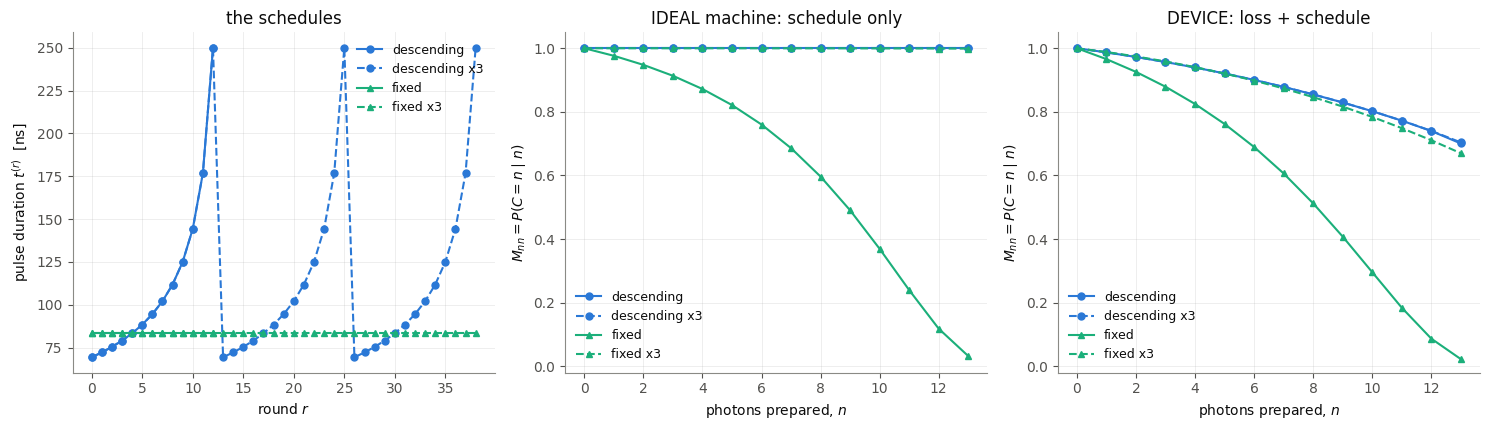

In [14]:
plt.rcParams.update({
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#8a8a85", "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "figure.facecolor": "white", "axes.facecolor": "white",
})

# Categorical colours, assigned in a fixed order and never cycled.
C_TRUE = "#2a78d6"        # slot 1, blue
C_MEAS = "#eb6834"        # slot 2, orange
C_UNF_IDEAL = "#1baf7a"   # slot 3, aqua
C_UNF_CLIMB = "#eda100"   # slot 4, yellow

# Colour carries the schedule family; the dash carries how many passes it makes, so
# identity is never colour alone.
SCHEDULE_STYLE = {
    "descending":    {"color": C_TRUE,      "marker": "o", "linestyle": "-"},
    NAME_DESC_REP:   {"color": C_TRUE,      "marker": "o", "linestyle": "--"},
    "fixed":         {"color": C_UNF_IDEAL, "marker": "^", "linestyle": "-"},
    NAME_FIXED_REP:  {"color": C_UNF_IDEAL, "marker": "^", "linestyle": "--"},
}

n_axis = np.arange(N_CAV)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

for name in SCHEDULES:
    times = SCHEDULES[name]
    axes[0].plot(np.arange(len(times)), np.array(times) * 1000.0,
                 markersize=5, label=name, **SCHEDULE_STYLE[name])
axes[0].set_xlabel("round $r$")
axes[0].set_ylabel("pulse duration $t^{(r)}$  [ns]")
axes[0].set_title("the schedules")
axes[0].legend(frameon=False, fontsize=9)

for ax, matrices, title in [(axes[1], M_noiseless, "IDEAL machine: schedule only"),
                            (axes[2], M_ideal_prep, "DEVICE: loss + schedule")]:
    for name in SCHEDULES:
        ax.plot(n_axis, np.diag(matrices[name]), markersize=5, label=name,
                **SCHEDULE_STYLE[name])
    ax.set_xlabel("photons prepared, $n$")
    ax.set_ylabel("$M_{nn} = P(C=n \\mid n)$")
    ax.set_title(title)
    ax.set_xticks(n_axis[::2])
    ax.set_ylim(-0.02, 1.05)
    ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

## 8. The confusion matrix, version B: Fock states climbed up the ladder

A real calibration cannot inject a perfect $\lvert n\rangle$. The usual construction is to **climb the
ladder** with the same hardware: for $f = 1, 2, \dots, n$,

$$ \lvert g, f-1\rangle \;\xrightarrow{\ \pi \text{ pulse}\ }\; \lvert e, f-1\rangle
   \;\xrightarrow{\ \text{pulse } t_f\ }\; \lvert g, f\rangle $$

which is a ladder of durations $t_1, t_2, \dots$ used *constructively* rather than as a cooling
sweep (`CLIMB_TIMES`, with its own propagators). Each rung costs another $t_\pi + t_f$ of exposure to the same
decoherence, and the errors accumulate: a photon lost on rung 3 is never recovered by rungs 4 through
$n$. Afterwards the qubit is reset (here: traced out), leaving the cavity in a **mixed** state
$\rho_{\rm prep}(n)$ that is not $\lvert n\rangle$.

Column $n$ of $M_{\rm climb}$ is the click distribution of that $\rho_{\rm prep}(n)$, so it folds
*preparation* errors and *counting* errors together and cannot tell them apart. That is the central
caveat of the whole technique, and section 10 shows what it costs.

In [15]:
def climb_prepare(n_target, climb_props):
    '''Prepare |n_target> by climbing the ladder, with decoherence acting throughout.

    Rung f:  pi pulse |g,f-1> -> |e,f-1>,  then the level-f pulse |e,f-1> -> |g,f>.
    climb_props must be built on CLIMB_TIMES, so climb_props["swaps"][f-1] is the
    full-swap propagator for level f.
    At the end the qubit is reset, which we model by tracing it out.
    Returns the cavity density matrix as a Qobj.
    '''
    rho = tensor(ket_g * ket_g.dag(), ket2dm(basis(N_CAV, 0))).full()   # start in |g,0>
    for f in range(1, n_target + 1):
        rho = evolve(climb_props["pi"], rho)          # idle during the pi pulse
        rho = X_pi @ rho @ X_pi                       # the pi pulse: one excitation into the qubit
        rho = evolve(climb_props["swaps"][f - 1], rho)  # swap it into the cavity: |e,f-1> -> |g,f>
    rho_joint = Qobj(rho, dims=[[2, N_CAV], [2, N_CAV]])
    return rho_joint.ptrace(1)                        # trace out the qubit (it gets reset)


def confusion_matrix_climb_prep(props, climb_props):
    '''M[c, n] = P(C = c | the ladder-climb attempt at |n> was run).'''
    M = np.zeros((C_MAX + 1, N_CAV))
    for n in range(N_CAV):
        rho_prep = climb_prepare(n, climb_props)
        p, _ = count_distribution(rho_prep, props)
        M[:, n] = p
    return M


M_climb_prep = {}
for name in SCHEDULES:
    M_climb_prep[name] = confusion_matrix_climb_prep(props_device[name],
                                                     props_climb_device)

# How good was the preparation itself, before any counting happened?
print("ladder preparation quality on the DEVICE:")
print(" n   <n|rho_prep|n>   <n> of rho_prep")
for n in range(N_CAV):
    rho_prep = climb_prepare(n, props_climb_device)
    populations = np.diag(rho_prep.full()).real
    print("%2d   %13.4f   %14.4f" % (n, populations[n], populations @ n_axis))

print()
print("schedule          cond(M_climb)   column deficit")
for name in SCHEDULES:
    print("%-16s  %13.1f  %15.2e"
          % (name, np.linalg.cond(M_climb_prep[name]),
             np.abs(M_climb_prep[name].sum(axis=0) - 1.0).max()))

# Sanity: on the ideal machine the climb is perfect, so the descending matrix is the identity.
M_climb_noiseless = confusion_matrix_climb_prep(props_ideal["descending"], props_climb_ideal)
print("\nno-loss climb matrix (descending) vs identity: max deviation = %.2e"
      % np.abs(M_climb_noiseless - np.eye(N_CAV)).max())

ladder preparation quality on the DEVICE:
 n   <n|rho_prep|n>   <n> of rho_prep
 0          1.0000           0.0000
 1          0.9987           0.9987
 2          0.9967           1.9957
 3          0.9940           2.9912
 4          0.9907           3.9856
 5          0.9867           4.9788
 6          0.9820           5.9711
 7          0.9767           6.9624
 8          0.9709           7.9527
 9          0.9645           8.9422
10          0.9575           9.9308
11          0.9499          10.9185
12          0.9419          11.9054
13          0.9333          12.8915

schedule          cond(M_climb)   column deficit
descending                  2.0         1.11e-15
descending x3               1.9         5.74e-05
fixed                     300.3         8.88e-16
fixed x3                    2.1         5.77e-05

no-loss climb matrix (descending) vs identity: max deviation = 6.66e-16


### A and B as heatmaps

For the `descending` schedule, the two calibrations side by side. The log colour scale is there because
the interesting structure is in the small off-diagonal entries. In both, essentially all the weight lies
on or *below* the drawn diagonal -- the plot has $c$ increasing upwards, so the allowed region
$c \le n$ appears underneath it -- and the leak away from the diagonal grows steadily with $n$.

The third panel shows that $M_{\rm climb}$ sits below $M_{\rm ideal}$ everywhere on the diagonal, with
a gap that widens with $n$: the climb spends longer and longer exposed to loss before the counting even
starts.

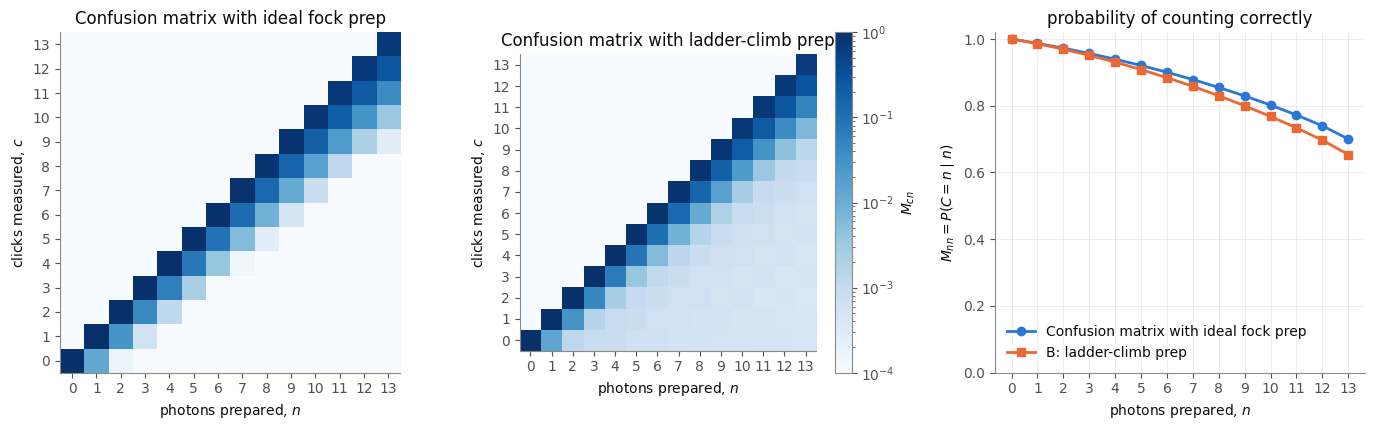

In [16]:
FLOOR = 1e-4              # a log colour scale needs a floor for the exact zeros

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))

for ax, M, title in [(axes[0], M_ideal_prep["descending"], "Confusion matrix with ideal fock prep"),
                     (axes[1], M_climb_prep["descending"], "Confusion matrix with ladder-climb prep")]:
    im = ax.imshow(np.clip(M, FLOOR, 1.0), origin="lower", cmap="Blues",
                   norm=LogNorm(vmin=FLOOR, vmax=1.0))
    ax.set_xlabel("photons prepared, $n$")
    ax.set_ylabel("clicks measured, $c$")
    ax.set_title(title) # descending schedule, device parameters
    ax.set_xticks(n_axis)
    ax.set_yticks(n_axis)
    ax.grid(False)
fig.colorbar(im, ax=axes[1], label="$M_{cn}$")

axes[2].plot(n_axis, np.diag(M_ideal_prep["descending"]), "-o", color=C_TRUE,
             linewidth=2, markersize=6, label="Confusion matrix with ideal fock prep")
axes[2].plot(n_axis, np.diag(M_climb_prep["descending"]), "-s", color=C_MEAS,
             linewidth=2, markersize=6, label="B: ladder-climb prep")
axes[2].set_xlabel("photons prepared, $n$")
axes[2].set_ylabel("$M_{nn} = P(C=n \\mid n)$")
axes[2].set_title("probability of counting correctly")
axes[2].set_xticks(n_axis)
axes[2].set_ylim(0, 1.02)
axes[2].legend(frameon=False)

fig.tight_layout()
plt.show()

## 9. Unfolding an unknown state

Because the response depends only on the photon-number populations (check 3 above), the measured click
distribution of *any* state is

$$ q_c \;=\; \sum_n M_{cn}\, p_n \qquad\Longleftrightarrow\qquad q = M p $$

so the honest estimate of the photon-number distribution is

$$ \hat p \;=\; M^{-1} q $$

This is exact linear algebra, not an approximation -- **provided $M$ is the response matrix that
actually generated $q$**. Two test states:

- a coherent state $\lvert\alpha\rangle$ with $\alpha = 1.8$ (a broad, Poisson-like $p_n$),
- a Fock superposition $\tfrac{1}{\sqrt3}\bigl(\lvert 0\rangle + \lvert 3\rangle + \lvert 7\rangle\bigr)$,
  whose true answer is three bins of exactly $1/3$ -- easy to check by eye, and it probes low, middle
  and high $n$ at once.

Each is measured on the real device, then unfolded twice: with $M_{\rm ideal}$ and with
$M_{\rm climb}$.

In [17]:
def unfold(M, q):
    '''Solve M p = q for the photon-number distribution p.'''
    return np.linalg.solve(M, q)


def total_variation(p, q):
    '''TVD = (1/2) sum_n |p_n - q_n|, the standard distance between two distributions.'''
    return 0.5 * np.abs(p - q).sum()


ALPHA = 2.2
psi_coherent = coherent(N_CAV, ALPHA)
psi_superposition = (basis(N_CAV, 0) + basis(N_CAV, 3) + basis(N_CAV, 7)).unit()

test_states = [("coherent, alpha = %.1f" % ALPHA, psi_coherent),
               ("(|0> + |3> + |7>)/sqrt(3)", psi_superposition)]

results = {}
for name, psi in test_states:
    p_true = np.abs(psi.full().flatten()) ** 2              # p_n = |<n|psi>|^2
    p_meas, _ = count_distribution(ket2dm(psi), props_device["descending"])
    p_unf_ideal = unfold(M_ideal_prep["descending"], p_meas)   # unfold with calibration A
    p_unf_climb = unfold(M_climb_prep["descending"], p_meas)   # unfold with calibration B
    results[name] = (p_true, p_meas, p_unf_ideal, p_unf_climb)

    print(name + "   (descending schedule, DEVICE)")
    print("   %-28s %14s   %6s" % ("", "TVD from truth", "<n>"))
    print("   %-28s %14s   %6.4f" % ("true p_n", "--", p_true @ n_axis))
    print("   %-28s %14.2e   %6.4f" % ("raw measured q_c",
                                       total_variation(p_meas, p_true), p_meas @ n_axis))
    print("   %-28s %14.2e   %6.4f" % ("unfolded with A (ideal prep)",
                                       total_variation(p_unf_ideal, p_true), p_unf_ideal @ n_axis))
    print("   %-28s %14.2e   %6.4f" % ("unfolded with B (climb prep)",
                                       total_variation(p_unf_climb, p_true), p_unf_climb @ n_axis))
    print()

coherent, alpha = 2.2   (descending schedule, DEVICE)
                                TVD from truth      <n>
   true p_n                                 --   4.8394
   raw measured q_c                   1.46e-02   4.7561
   unfolded with A (ideal prep)       2.12e-16   4.8394
   unfolded with B (climb prep)       3.60e-03   4.8620

(|0> + |3> + |7>)/sqrt(3)   (descending schedule, DEVICE)
                                TVD from truth      <n>
   true p_n                                 --   3.3333
   raw measured q_c                   5.49e-02   3.2763
   unfolded with A (ideal prep)       3.44e-16   3.3333
   unfolded with B (climb prep)       9.69e-03   3.3489



### The same test, for all three schedules

If the confusion matrix really is the whole story, then unfolding with the matching $M$ must be exact
**no matter how bad the schedule is** -- a schedule that fails to cool the cavity is just a different
linear map, not a broken one. The table below checks that: the raw measurement gets steadily worse from
`descending` to `fixed`, and the unfolded result stays at round-off in every case.

In [18]:
p_true_coh = np.abs(psi_coherent.full().flatten()) ** 2

print("coherent alpha = %.1f on the DEVICE, unfolded with its own matrix A:" % ALPHA)
print("schedule          TVD raw   |M p_true - q|   TVD unfolded    <n> raw   <n> unfolded")
for name in SCHEDULES:
    q, _ = count_distribution(ket2dm(psi_coherent), props_device[name])
    p_hat = unfold(M_ideal_prep[name], q)
    forward = M_ideal_prep[name] @ p_true_coh          # the model, run forwards: q = M p
    print("%-16s  %9.5f  %14.2e  %13.2e  %9.4f  %13.4f"
          % (name, total_variation(q, p_true_coh), np.abs(forward - q).max(),
             total_variation(p_hat, p_true_coh), q @ n_axis, p_hat @ n_axis))
print()
print("true <n> = %.4f" % (p_true_coh @ n_axis))
print()
print("The middle column is the forward statement q = M p checked directly against a full")
print("simulation of the coherent state: the matrix IS the apparatus, not a fit to it.")

coherent alpha = 2.2 on the DEVICE, unfolded with its own matrix A:
schedule          TVD raw   |M p_true - q|   TVD unfolded    <n> raw   <n> unfolded
descending          0.01464        8.33e-17       2.12e-16     4.7561         4.8394
descending x3       0.01463        1.67e-16       2.84e-16     4.7561         4.8394
fixed               0.04942        1.94e-16       2.66e-16     4.5536         4.8394
fixed x3            0.01497        1.67e-16       4.18e-16     4.7542         4.8394

true <n> = 4.8394

The middle column is the forward statement q = M p checked directly against a full
simulation of the coherent state: the matrix IS the apparatus, not a fit to it.


### Reading the numbers

Three things should stand out.

1. **Unfolding with the matching $M$ is exact.** Its TVD from the truth is at the $10^{-16}$ level --
   round-off, nothing else, for every schedule. That is the proof that the picture is right: the
   response really is linear in $p_n$, the matrix really is that response, and the inverse really
   undoes it.
2. **The raw measurement is biased low**, and gets worse as the schedule gets worse. Its
   $\langle n\rangle$ falls short of the truth by the photons that vanished without clicking.
3. **Unfolding with $M_{\rm climb}$ over-corrects.** That matrix was calibrated on states that were
   *already* missing photons, so it credits the detector with losses that happened during preparation
   and hands back too much probability at high $n$. It lands on the far side of the truth from the raw
   data -- an over-correction, not a residual under-correction.

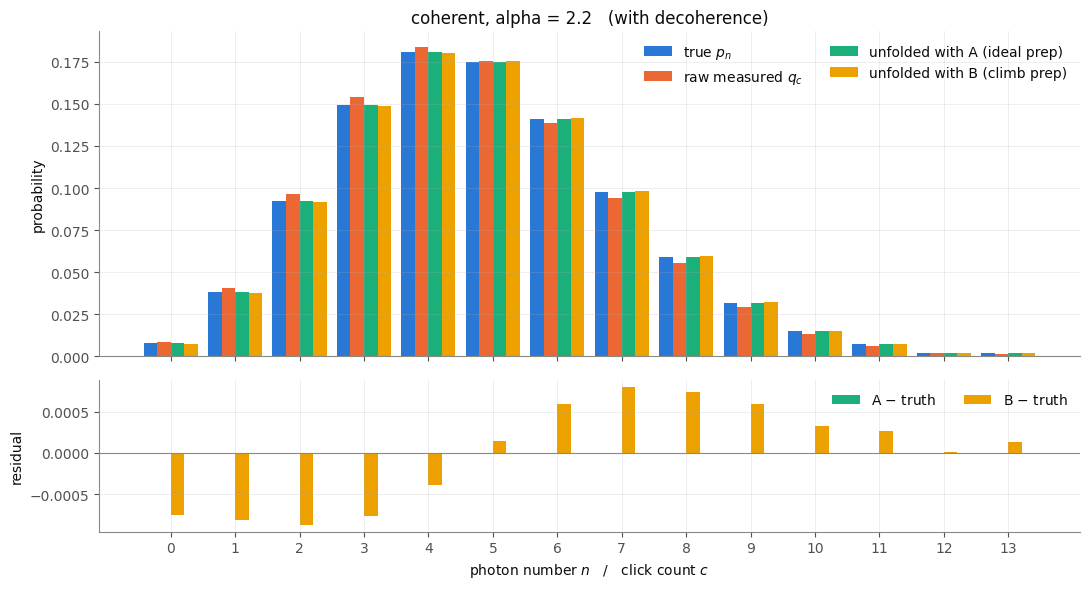

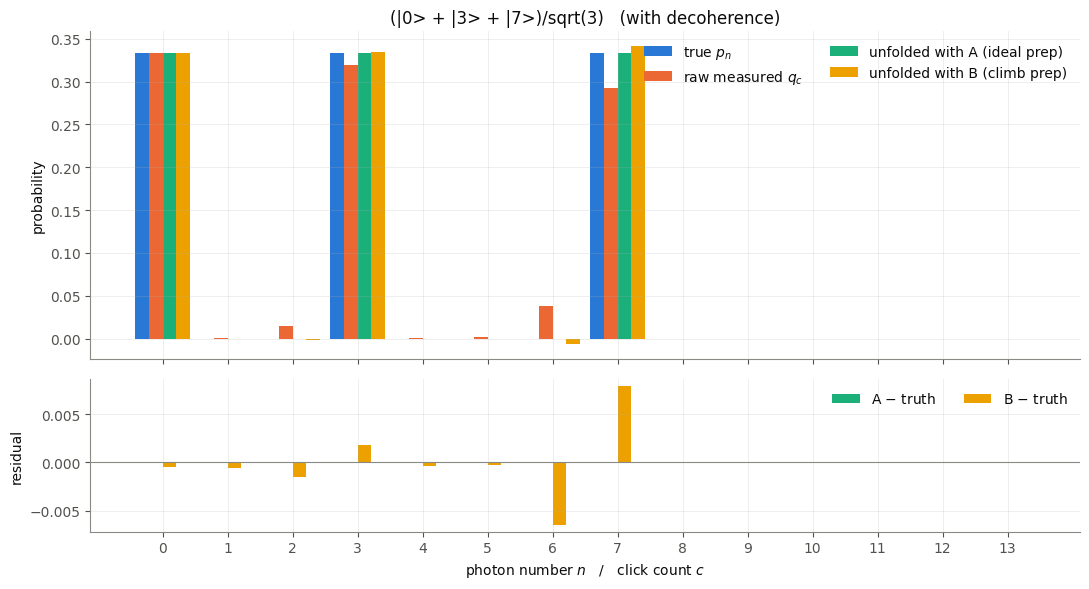

In [19]:
def plot_unfolding(name, p_true, p_meas, p_unf_ideal, p_unf_climb):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1.4]})
    w = 0.21
    ax1.bar(n_axis - 1.5 * w, p_true, width=w, color=C_TRUE, label="true $p_n$")
    ax1.bar(n_axis - 0.5 * w, p_meas, width=w, color=C_MEAS, label="raw measured $q_c$")
    ax1.bar(n_axis + 0.5 * w, p_unf_ideal, width=w, color=C_UNF_IDEAL,
            label="unfolded with A (ideal prep)")
    ax1.bar(n_axis + 1.5 * w, p_unf_climb, width=w, color=C_UNF_CLIMB,
            label="unfolded with B (climb prep)")
    ax1.set_ylabel("probability")
    ax1.set_title(name + "   (with decoherence)")
    ax1.legend(frameon=False, ncol=2)

    ax2.axhline(0.0, color="#8a8a85", linewidth=0.8)
    ax2.bar(n_axis - w / 2, p_unf_ideal - p_true, width=w, color=C_UNF_IDEAL, label="A $-$ truth")
    ax2.bar(n_axis + w / 2, p_unf_climb - p_true, width=w, color=C_UNF_CLIMB, label="B $-$ truth")
    ax2.set_xlabel("photon number $n$   /   click count $c$")
    ax2.set_ylabel("residual")
    ax2.set_xticks(n_axis)
    ax2.legend(frameon=False, ncol=2)

    fig.tight_layout()
    plt.show()


for name, _ in test_states:
    p_true, p_meas, p_unf_ideal, p_unf_climb = results[name]
    plot_unfolding(name, p_true, p_meas, p_unf_ideal, p_unf_climb)

### A worked example, bin by bin: $\tfrac{1}{\sqrt3}\bigl(\lvert 1\rangle + \lvert 4\rangle + \lvert 9\rangle\bigr)$

Three equally weighted Fock lines, spread far enough apart that each one sits in a different loss
regime: $\lvert 1\rangle$ has a single photon to hold for the whole run, $\lvert 9\rangle$ has nine.
The truth is exactly $p_1 = p_4 = p_9 = 1/3$ and zero everywhere else, so **every nonzero number in
any other bin below is the machine, not the state**.

What the measured distribution does to those three lines is the whole thesis of the notebook in one
table. Each line keeps a fraction $M_{nn}$ of its weight in the right bin and smears the rest
*downwards* into the bins beneath it -- never upwards, apart from the tiny $\pi$-pulse channel. The
smearing grows steeply with $n$, so the three lines are degraded by visibly different amounts. That is
what makes the raw histogram a **biased** photon-number readout rather than merely a noisy one, and it
is exactly the bias $M^{-1}$ removes.

(|1> + |4> + |9>)/sqrt(3),  descending schedule on the DEVICE

  c/n     true p_n   measured q_c   unfolded A   unfolded B
    0      0.00000        0.00434      0.00000     -0.00086
    1      0.33333        0.32899      0.33333      0.33328
    2      0.00000        0.00041      0.00000     -0.00048
    3      0.00000        0.01975      0.00000     -0.00247
    4      0.33333        0.31316      0.33333      0.33626
    5      0.00000        0.00001     -0.00000     -0.00024
    6      0.00000        0.00015      0.00000     -0.00042
    7      0.00000        0.00397     -0.00000     -0.00016
    8      0.00000        0.05269      0.00000     -0.01053
    9      0.33333        0.27650      0.33333      0.34562
   10      0.00000        0.00002     -0.00000      0.00000
   11      0.00000        0.00000      0.00000     -0.00000
   12      0.00000        0.00000     -0.00000      0.00000
   13      0.00000        0.00000      0.00000     -0.00000
  ----     --------   ------------   

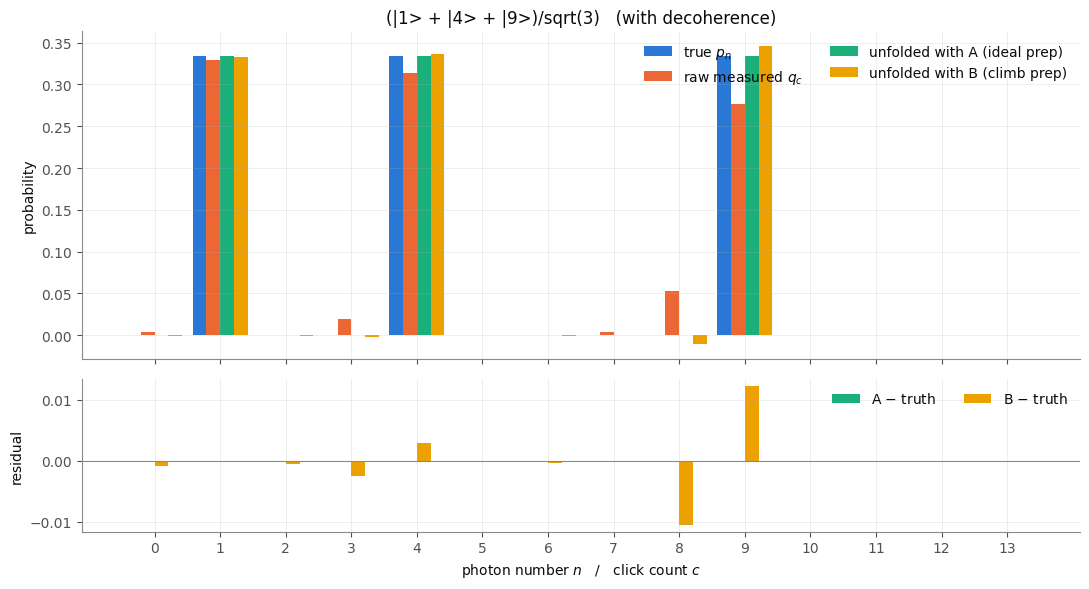

In [20]:
psi_149 = (basis(N_CAV, 1) + basis(N_CAV, 4) + basis(N_CAV, 9)).unit()

p_true_149 = np.abs(psi_149.full().flatten()) ** 2               # exactly 1/3 at n = 1, 4, 9
p_meas_149, _ = count_distribution(ket2dm(psi_149), props_device["descending"])
p_unf_A_149 = unfold(M_ideal_prep["descending"], p_meas_149)     # calibration A: ideal Fock prep
p_unf_B_149 = unfold(M_climb_prep["descending"], p_meas_149)     # calibration B: ladder-climb prep

print("(|1> + |4> + |9>)/sqrt(3),  descending schedule on the DEVICE")
print()
print("  c/n     true p_n   measured q_c   unfolded A   unfolded B")
for n in range(N_CAV):
    print("   %2d     %8.5f   %12.5f   %10.5f   %10.5f"
          % (n, p_true_149[n], p_meas_149[n], p_unf_A_149[n], p_unf_B_149[n]))
print("  ----     --------   ------------   ----------   ----------")
print("   sum    %8.5f   %12.5f   %10.5f   %10.5f"
      % (p_true_149.sum(), p_meas_149.sum(), p_unf_A_149.sum(), p_unf_B_149.sum()))
print("   <n>    %8.4f   %12.4f   %10.4f   %10.4f"
      % (p_true_149 @ n_axis, p_meas_149 @ n_axis,
         p_unf_A_149 @ n_axis, p_unf_B_149 @ n_axis))
print("   TVD           --   %12.2e   %10.2e   %10.2e"
      % (total_variation(p_meas_149, p_true_149),
         total_variation(p_unf_A_149, p_true_149),
         total_variation(p_unf_B_149, p_true_149)))

# Where each line's weight went. Column n of M is exactly the fate of the |n> line,
# so this reads the smearing straight off the confusion matrix.
print("\n  fate of each Fock line (column n of M, scaled by its weight 1/3):")
print("  line    stays at c = n   leaks to c < n   leaks to c > n")
for n_line in [1, 4, 9]:
    column = M_ideal_prep["descending"][:, n_line]
    stays = column[n_line]
    leaks_down = column[:n_line].sum()
    leaks_up = column[n_line + 1:].sum()
    print("  |%d>    %14.4f   %14.4f   %14.6f" % (n_line, stays, leaks_down, leaks_up))

plot_unfolding("(|1> + |4> + |9>)/sqrt(3)", p_true_149, p_meas_149, p_unf_A_149, p_unf_B_149)

## 10. What the ladder-prep calibration actually costs

The bias above is systematic, so it does not average away with more shots. A cleaner way to see it:
feed both matrices the same data and ask what each thinks was in the cavity. The systematic error
operator is

$$ M_{\rm climb}^{-1} M_{\rm ideal} \;\ne\; \mathbb{1} $$

and its column $n$ is the distorted answer calibration B returns for a true $\lvert n\rangle$. The mean
photon number it reports, $\sum_c c\,\bigl[M_{\rm climb}^{-1}M_{\rm ideal}\bigr]_{cn}$, drifts *above*
the true $n$, and the drift grows with $n$ -- the signature of blaming the detector for preparation
loss.

In [21]:
bias_operator = np.linalg.solve(M_climb_prep["descending"], M_ideal_prep["descending"])

print("what calibration B reports for a true |n>  (descending schedule):")
print(" n   reported <n>   error")
for n in range(N_CAV):
    reported = bias_operator[:, n] @ n_axis
    print("%2d   %12.4f   %+6.4f" % (n, reported, reported - n))

print()
print("deviation from the identity: max |M_climb^-1 M_ideal - 1| = %.4f"
      % np.abs(bias_operator - np.eye(N_CAV)).max())

what calibration B reports for a true |n>  (descending schedule):
 n   reported <n>   error
 0         0.0000   +0.0000
 1         1.0013   +0.0013
 2         2.0043   +0.0043
 3         3.0088   +0.0088
 4         4.0145   +0.0145
 5         5.0213   +0.0213
 6         6.0291   +0.0291
 7         7.0379   +0.0379
 8         8.0477   +0.0477
 9         9.0584   +0.0584
10        10.0700   +0.0700
11        11.0824   +0.0824
12        12.0957   +0.0957
13        13.1098   +0.1098

deviation from the identity: max |M_climb^-1 M_ideal - 1| = 0.0714


## 11. Finite shots: the price of inverting a matrix

Everything so far used the exact $q$. A real experiment estimates $q$ from $N_{\rm shots}$ runs, and
$M^{-1}$ amplifies that noise. If $\hat q$ is a multinomial estimate then

$$ \operatorname{Cov}(\hat q) = \frac{\operatorname{diag}(q) - qq^{\mathsf T}}{N_{\rm shots}},
   \qquad
   \operatorname{Cov}(\hat p) = M^{-1}\operatorname{Cov}(\hat q)\,M^{-\mathsf T} $$

$\operatorname{cond}(M)$ bounds the amplification, and it is where the schedules separate on paper:
$\approx 2$ for `descending`, `descending x3` and `fixed x3`, all of which are triangular with a strong
diagonal, against $\approx 300$ for single-pass `fixed`, whose diagonal collapses at high $n$.

That bound is worst-case over every direction in $q$, and a real measurement rarely points along the
worst one. The table below reports the *realised* amplification -- the largest error bar on $\hat p$
divided by the raw $1/\sqrt N$ noise on $\hat q$ -- and for this coherent state every schedule comes out
near $1\times$, `fixed` included. A large condition number is a warning about what could go wrong, not
a measurement of what did.

What single-pass `fixed` actually costs shows up in two other places. Its raw distribution starts much
further from the truth (TVD $0.037$ against $0.015$), so unfolding has more work to do. And
$M^{-1}\hat q$ dips **negative** in low-population bins, because it is an unbiased estimator, not a
probability distribution. Constraining the fit to be non-negative (`scipy.optimize.nnls`: minimise
$\lVert M\hat p - \hat q\rVert$ subject to $\hat p \ge 0$) removes that. At $2\times10^4$ shots the
excursions are only $\sim 4\times10^{-4}$ deep and the constraint improves the answer by a few percent;
drop `N_SHOTS`, or lengthen the run against $T_1$, and it starts to earn its keep properly.

coherent alpha = 2.2, 20000 shots, unfolded with calibration A:
schedule          cond(M)   sigma_p max   amplif.   TVD raw   TVD M^-1   TVD nnls   min bin
descending            1.8       0.00298      0.8x   0.01543    0.00703    0.00703   +0.00178
descending x3         1.8       0.00298      0.8x   0.01964    0.00786    0.00786   +0.00185
fixed               274.7       0.00866      2.4x   0.04904    0.02874    0.01746   -0.01004
fixed x3              1.9       0.00299      0.8x   0.01604    0.01628    0.01628   +0.00164

shot noise on q itself: 0.00354  (~1/sqrt(N), before any unfolding)
'amplif.' is sigma_p max divided by that: what inverting M costs in error bar.
Shots needed for a given precision scale as the square of it.


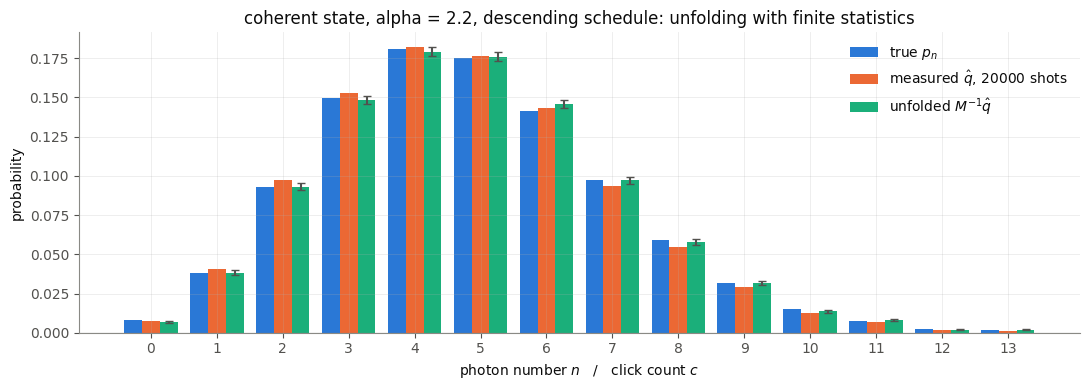

In [22]:
N_SHOTS = 20000
rng = np.random.default_rng(0)

shot_noise_on_q = np.sqrt(0.25 / N_SHOTS)      # the ~1/sqrt(N) scale we start from

shot_results = {}
print("coherent alpha = %.1f, %d shots, unfolded with calibration A:" % (ALPHA, N_SHOTS))
print("schedule          cond(M)   sigma_p max   amplif.   TVD raw   TVD M^-1   TVD nnls   min bin")
for name in SCHEDULES:
    M = M_ideal_prep[name]
    q_exact, _ = count_distribution(ket2dm(psi_coherent), props_device[name])

    # sample N_SHOTS runs from the exact click distribution
    q_hat = rng.multinomial(N_SHOTS, q_exact) / N_SHOTS

    # the unbiased linear estimate, and its error bars
    p_hat = np.linalg.solve(M, q_hat)
    cov_q = (np.diag(q_exact) - np.outer(q_exact, q_exact)) / N_SHOTS   # multinomial covariance
    M_inv = np.linalg.inv(M)
    cov_p = M_inv @ cov_q @ M_inv.T                                    # propagate through M^-1
    sigma_p = np.sqrt(np.diag(cov_p))

    # non-negative least squares: the same fit, constrained to be a real distribution
    p_nnls, _ = nnls(M, q_hat)
    p_nnls = p_nnls / p_nnls.sum()

    shot_results[name] = (q_hat, p_hat, sigma_p, p_nnls)
    print("%-16s %8.1f  %12.5f  %7.1fx  %8.5f  %9.5f  %9.5f  %+9.5f"
          % (name, np.linalg.cond(M), sigma_p.max(), sigma_p.max() / shot_noise_on_q,
             total_variation(q_hat, p_true_coh), total_variation(p_hat, p_true_coh),
             total_variation(p_nnls, p_true_coh), p_hat.min()))

print()
print("shot noise on q itself: %.5f  (~1/sqrt(N), before any unfolding)" % shot_noise_on_q)
print("'amplif.' is sigma_p max divided by that: what inverting M costs in error bar.")
print("Shots needed for a given precision scale as the square of it.")

q_hat, p_hat, sigma_p, p_nnls = shot_results["descending"]
fig, ax = plt.subplots(figsize=(11, 4))
w = 0.27
ax.bar(n_axis - w, p_true_coh, width=w, color=C_TRUE, label="true $p_n$")
ax.bar(n_axis, q_hat, width=w, color=C_MEAS, label="measured $\\hat q$, %d shots" % N_SHOTS)
ax.bar(n_axis + w, p_hat, width=w, color=C_UNF_IDEAL, yerr=sigma_p, capsize=3,
       ecolor="#52514e", label="unfolded $M^{-1}\\hat q$")
ax.axhline(0.0, color="#8a8a85", linewidth=0.8)
ax.set_xlabel("photon number $n$   /   click count $c$")
ax.set_ylabel("probability")
ax.set_title("coherent state, alpha = %.1f, descending schedule: unfolding with finite statistics"
             % ALPHA)
ax.set_xticks(n_axis)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Summary

- **The schedule matters, and only one is exact in a single pass.** `descending` -- short pulses first,
  lengthening to $t_1=\pi/2g$ -- walks the ladder down one rung per round and empties a state of
  support $R$ in exactly $R$ rounds. The same durations in the opposite order do not, and one fixed
  pulse length cannot, because $\sin^2(gt\sqrt n)$ can equal 1 at only one level. On the ideal machine
  `descending` gives $M = \mathbb 1$ and the single-pass others do not.
- **Rounds can buy back what pulse shaping cannot.** Running the fixed pulse for $3R$ rounds instead of
  $R$ turns the worst schedule into a usable one: on the ideal machine its $M$ comes within $10^{-3}$
  of the identity, the residual $\langle n\rangle$ drops from $0.11$ to $7\times10^{-5}$, and
  $\operatorname{cond}(M)$ collapses from $302$ to $2.2$. The fixed schedule was never fundamentally
  blind -- every round has a decent chance of knocking any level down a rung -- it was just impatient.
- **Repeating an already-exact sweep buys almost nothing.** `descending x3` cools further still
  ($5\times10^{-5} \to 3\times10^{-15}$) but its confusion matrix is unchanged to three digits, because
  after the first pass the cavity is empty and the extra rounds have no photons left to act on. They
  are not free, though: three times the $\pi$ pulses means three times the overcounting channel below.
- **Loss adds a second, independent failure.** With realistic $T_1$, $T_2$ and gate times, $M$ stays
  upper triangular to a part in $10^3$ -- errors almost only move probability to *lower* click
  counts -- while its diagonal falls off with $n$: high Fock states are undercounted, because they have
  more photons to lose and take longer to read out.
- **The one overcounting channel is the reset pulse.** A $\pi$ pulse fired at a qubit that relaxed
  since the readout puts a fake excitation back into the system, which the cavity later absorbs and the
  counter later counts. It scales as $t_\pi/T_1^q$ and vanishes identically at $t_\pi=0$.
- **One matrix captures both.** The response depends only on the photon-number populations $p_n$ --
  a symmetry statement, since every element of the protocol commutes with the total-excitation
  rotation -- so the apparatus is exactly a linear map $q = Mp$, whatever is wrong with it.
- **Inverting the right matrix is exact.** Unfolding with the matrix that generated the data recovers
  the truth to round-off, for every schedule, including ones that never cool the cavity. This is a
  consistency check on the simulation, not an experimental claim -- nobody has an ideal Fock source.
- **Inverting the achievable matrix over-corrects.** A calibration built from **ladder-climbed** Fock
  states silently attributes preparation loss to the detector and reports more high-$n$ population than
  is really there. The size of that bias is $M_{\rm climb}^{-1}M_{\rm ideal} - \mathbb 1$.
- **Conditioning is a warning, not a verdict.** $\operatorname{cond}(M)$ is $\approx 2$ for
  `descending` and `fixed x3` but $\approx 300$ for single-pass `fixed`. That is a worst-case bound
  over all directions in $q$, and at $2\times10^4$ shots every schedule here realises only $\approx 1
  \times$ the raw shot noise, so the threatened amplification never materialises for this state. What
  does show up is what a poorly conditioned $M$ always predicts: negative bins in $M^{-1}\hat q$,
  cured by a non-negative fit. Keeping the schedule well conditioned is still the cheap insurance,
  because nothing guarantees the next state points in a harmless direction.

### Things to try

- Set `FIXED_LEVEL = 1`. The fixed schedule then has $\sin^2(\tfrac\pi2\sqrt 4) = 0$, so
  $\lvert 4\rangle$ is perfectly invisible, the $n=0$ and $n=4$ columns of the noiseless $M$ coincide,
  and the matrix is exactly singular. Loss makes it merely near-singular, which is worse: it inverts,
  and the answer is garbage.
- Raise `C_MAX` above $N-1$ so the repeated schedules stop dropping their overcount weight, and unfold
  the resulting non-square $M$ with a least-squares pseudo-inverse.
- Sweep `N_PASSES` for the fixed schedule and find where the two competing trends cross: more rounds
  cool better, but each round adds $t_m + t_\pi$ of exposure. There is an optimum, and it moves with
  $T_1^{c}$.
- Shorten `T_MEAS`. The readout window dominates the run time, so it dominates the confusion.
- Push `T1_CAV` down toward the run duration and watch the diagonal vanish; past some point
  $\operatorname{cond}(M)$ blows up and no number of shots will unfold it.
- Set `t_pi=0.0, t_meas=0.0` in `DEVICE` but keep the coherence times finite, to isolate the loss that
  happens during the pulses alone.
- Add a readout infidelity: replace the projectors with a POVM that reports $\lvert e\rangle$ with
  probability $1-\epsilon$. That adds an $n$-independent smearing on top of the $n$-dependent loss, and
  the two remain separable in $M$.

## 12. The Markov reading of the record

Everything above turns a record into a **click count** and unfolds the click histogram. This
section builds the other reading, the one the hardware runtime uses in production: score the
whole *ordered* bit string against every candidate initial photon number with a hidden Markov
chain, and assign the shot to the best one.

The full derivation is in `jc_counting_markov_model.md` next to this notebook. The
implementation is the `MARKOV ANALYSIS` section at the bottom of
`msmt_workbench/rfsoc/runtimes/quantum_simulation/resonator_number_measurement.py`, and this
section **imports it directly** rather than reimplementing it — so what is tested here is the
code that runs on the data.

Why bother? Because the click count merges records that are not the same measurement:

```
A:  1 1 1 0 0 0 0 0 0 0 0 0 0     three clicks, at the rounds tuned to levels 8, 7, 6
B:  0 0 0 0 0 0 0 0 0 0 1 1 1     three clicks, at the level-1 mop-up rounds
```

Both say "3 photons" to a click counter. But population that only clicks in the *late*
level-1 rounds was sitting at n = 1 the whole time, so three late clicks are better explained
by a qubit that heated twice than by three photons. The Markov chain knows when each round
happened and can tell them apart; the click count cannot.

**The test below is deliberately not circular.** The records are drawn from the *full Lindblad
master equation* of section 5 — with cavity dephasing and qubit T2, neither of which the
Markov model contains — and the classifier is then asked to recover the truth. It is being
scored on data generated by a richer physics than it assumes.

In [ ]:
# The Markov analysis, imported from the runtime that ships it.
import sys
sys.path.insert(0, "/home/boson/msmt_workbench")

from msmt_workbench.rfsoc.runtimes.quantum_simulation.resonator_number_measurement import (
    counting_hmm_model,        # assemble the per-round matrices
    classify_photon_number,    # argmax + posterior over candidate photon numbers
    counting_loglikelihood,    # log P(string | n), the forward algorithm
    swap_map,                  # one ladder swap as a population map
    enumerate_bitstrings,      # every string a run of R rounds can produce
    bitstring_index,           # inverse of the above
    unfold_distribution,       # least squares + nnls through a confusion matrix
)

# ---- UNITS -------------------------------------------------------------------------
# The runtime works in seconds; this notebook works in microseconds. Every time entering
# the model is a RATIO against another time (theta = pi t / t_n, decay = t / T1), so one
# consistent unit is all that is required. Everything below stays in microseconds.

# ---- the schedule the hardware runtime actually plays ------------------------------
# fock_ladder_top descending rounds, then count_extra_rounds level-1 mop-up rounds. This
# mirrors Resonator_number_measurement exactly, so the numbers here are comparable to the
# ones the real runtime prints.
MK_TOP = 8            # highest Fock state prepared, and the level the descent starts from
MK_EXTRA = 5          # level-1 mop-up rounds after the descent
MK_FOCK = MK_TOP + 1  # candidate photon numbers 0..8, i.e. the columns of M'
MK_TRUNC = MK_TOP + 2 # cavity truncation for the MODEL: headroom above the top prep

n_ax = np.arange(MK_FOCK)          # the photon-number axis, used throughout

mk_levels = list(range(MK_TOP, 0, -1)) + [1] * MK_EXTRA
mk_times = [swap_time(level) for level in mk_levels]          # us, effective swap area
MK_ROUNDS = len(mk_levels)

# full-swap time of level n, indexed BY LEVEL; entry 0 is unused (the model reads 1..N)
mk_level_times = np.array([np.nan] + [swap_time(n) for n in range(1, MK_TRUNC + 1)])

print("the counting schedule this section models")
print("  round   " + "".join(f"{r:6d}" for r in range(MK_ROUNDS)))
print("  level   " + "".join(f"{L:6d}" for L in mk_levels))
print("  t [ns]  " + "".join(f"{t*1000:6.0f}" for t in mk_times))
print(f"\n  {MK_ROUNDS} rounds of pulses = {sum(mk_times):.2f} us")
print(f"  + readout {MK_ROUNDS * T_MEAS:.2f} us + up to {MK_TOP * T_PI:.2f} us of pi pulses")
print(f"  -> a shot lasts about {sum(mk_times) + MK_ROUNDS*T_MEAS + MK_TOP*T_PI:.1f} us, "
      f"i.e. {(sum(mk_times) + MK_ROUNDS*T_MEAS)/T1_CAV:.1%} of the cavity T1")

### The swap transfer table: why the model needs the level *and* the length

A round of duration $t$ rotates the $|g,n\rangle \leftrightarrow |e,n-1\rangle$ transition by
$\theta_n = \pi t / t_n$, so it is a full swap **only** on the level it was tuned to. What it
does everywhere else is the information the classification is built from.

Read the table below along a row: one round, acting on every photon number. Two things should
stand out. The diagonal is 1.000 — each round is a full swap on its own level, as designed.
And the off-diagonal entries are not a product of a per-round factor and a per-level factor —
no single number could reproduce this, which is exactly why the model has to know both.

Look in particular at the level-1 rounds acting on $|4\rangle$: **0.000**. Not a bug —
$\theta_4 = \pi t_1/t_4 = 2\pi$, a *double* swap, which puts the population back where it
started. Under the $\sqrt{n}$ law a level-4 population is invisible to a level-1 pulse.

In [ ]:
# One row per round, one column per photon number: P(the round moves |n> down by one).
print("P(transfer) for each round of the schedule, from swap_map() -- the model's own view")
print("  round level |" + "".join(f"  n={n}" for n in range(1, MK_FOCK)))
mk_transfer = np.zeros((MK_ROUNDS, MK_FOCK - 1))
for r, (level, t) in enumerate(zip(mk_levels, mk_times)):
    S = swap_map(MK_TRUNC, t, mk_level_times, transfer_scale=1.0)
    # |g,n> is index 2n, |e,n-1> is index 2(n-1)+1
    mk_transfer[r] = [S[2 * n, 2 * (n - 1) + 1] for n in range(1, MK_FOCK)]
    print(f"  r{r:<4d} L{level:<4d}|" + "".join(f" {v:5.3f}" for v in mk_transfer[r]))

print("\nspread ACROSS rounds for a fixed n : %.3f  (if ~0, the length is not reaching the model)"
      % mk_transfer.ptp(axis=0).max())
print("spread ACROSS n for a fixed round  : %.3f  (if ~0, the Fock dependence is missing)"
      % mk_transfer.ptp(axis=1).max())

### Sampling records from the full master equation

To score the classifier we need **bit strings**, not click distributions — and they have to
come from physics the classifier does not know, or the test proves nothing.

`count_distribution` above keeps one unnormalised $\rho$ per click count, which is exact but
discards the ordering. Here we do the opposite: track **one normalised $\rho$ per shot** and
sample the record as we go. Per round:

1. apply the round's Lindblad propagator (drive on) and then the readout-window propagator
   (drive off, decoherence still running);
2. compute $p_e = \mathrm{tr}(P_e \rho P_e)$ and draw the **true** outcome from it;
3. project $\rho$ onto that outcome and renormalise — this is the measurement back-action, and
   it is what makes the record correlated with the state;
4. flip the bit with probability $\varepsilon$ to model readout misassignment, and record the
   **flipped** bit;
5. fire the reset $\pi$ if the *recorded* bit is 1 — on hardware the feedback acts on what the
   CMACC decided, not on the truth, so a misread costs you a spurious $\pi$ too.

That is exact sampling of the joint (record, state) distribution. The propagators carry
cavity photon loss, **cavity dephasing** and **qubit $T_2$** — the last two are entirely
absent from the Markov model, which is the point.

Batched over shots so it runs in seconds rather than minutes.

In [ ]:
# vec() column-stacks, so a batch of vec'd matrices unpacks as reshape-then-transpose:
# a column-major flatten of M is a row-major flatten of M.T.
def vec_batch(rho):
    '''(n, D, D) density matrices -> (n, D*D) column-stacked vectors.'''
    return rho.transpose(0, 2, 1).reshape(rho.shape[0], -1)


def unvec_batch(V):
    '''(n, D*D) column-stacked vectors -> (n, D, D) density matrices.'''
    return V.reshape(V.shape[0], D, D).transpose(0, 2, 1)


def sample_records(rho_cavity, props, n_shots, readout_error=0.0, rng=None):
    '''Draw measurement records from the FULL master equation, one normalised rho per shot.

    rho_cavity    : Qobj, the cavity state the prep leaves behind (the qubit starts in |g>)
    props         : build_propagators() output whose "swaps" list IS the schedule to run
    readout_error : probability the recorded bit differs from the projected outcome
    returns       : int8 array (n_shots, n_rounds) of recorded bits, 0 = g, 1 = e

    Batched over shots: rho for every shot is held as one (n_shots, D*D) array and a
    superoperator is applied as a single matmul (V @ S.T when the shots are rows).
    '''
    rng = np.random.default_rng() if rng is None else rng
    rounds = props["swaps"]
    rho0 = tensor(ket_g * ket_g.dag(), rho_cavity).full()
    V = np.repeat(vec(rho0)[None, :], n_shots, axis=0).astype(complex)
    record = np.zeros((n_shots, len(rounds)), dtype=np.int8)

    for r, S_pulse in enumerate(rounds):
        V = V @ S_pulse.T                          # the Jaynes-Cummings pulse of this round
        V = V @ props["meas"].T                    # readout window: no drive, decoherence on

        rho = unvec_batch(V)
        norm = np.trace(rho, axis1=1, axis2=2).real
        # P_e is a projector, so tr(P_e rho P_e) = tr(P_e rho)
        p_e = np.clip(np.einsum("ij,sji->s", P_e, rho).real / norm, 0.0, 1.0)
        truth = rng.random(n_shots) < p_e                  # the outcome that really happened

        # measurement back-action: project onto that outcome and renormalise. This is what
        # correlates the record with the state, and it is what the click count discards.
        proj = np.where(truth[:, None, None], P_e[None, :, :], P_g[None, :, :])
        rho = proj @ rho @ proj
        rho /= np.trace(rho, axis1=1, axis2=2).real[:, None, None]

        # readout misassignment. The reset fires on the RECORDED bit, because on hardware the
        # feedback acts on what the CMACC decided -- so a misread also costs a spurious pi.
        recorded = np.logical_xor(truth, rng.random(n_shots) < readout_error)
        record[:, r] = recorded

        V = vec_batch(rho)
        clicked = np.flatnonzero(recorded)
        if clicked.size:
            V[clicked] = V[clicked] @ props["pi"].T        # idle during the pi pulse ...
            flipped = X_pi @ unvec_batch(V[clicked]) @ X_pi   # ... then the flip itself
            V[clicked] = vec_batch(flipped)
    return record


# the schedule this section studies, on the DEVICE and on a lossless machine
props_mk_device = build_propagators(DEVICE, mk_times)
props_mk_ideal = build_propagators(IDEAL, mk_times)
print("propagators built for the %d-round runtime schedule" % MK_ROUNDS)

### Check the sampler before trusting it — and one surprise

Two invariants, either of which would catch a wrong projection or a wrong feedback branch:

1. On a **lossless** machine with a **perfect** readout, preparing $|n\rangle$ must give exactly
   $n$ clicks — every shot, no spread. Photons cannot be created or destroyed, so the count is
   exact.
2. On the **device**, the mean click count is pulled two ways and the balance flips with $n$:
   *photons lost before their round* undercount, and that grows with $n$ (the $n/T_1$
   enhancement); *readout misassignment and the $\pi$-pulse re-excitation channel of section 7*
   overcount, at a roughly constant rate per round. At low $n$ the spurious clicks win and the
   mean sits **above** $n$; at high $n$ the loss wins and it sits below.

The surprise is what invariant 1 does **not** say. Exactly $n$ clicks does not mean the same
*string* every time, and only one prep gives a deterministic record:

- $|8\rangle$, the top of the ladder, is deterministic. Round 0 is tuned to level 8 and fully
  swaps it; round 1 is tuned to level 7 and fully swaps what is now there; and so on. The
  record is `1111111100000` every single shot.
- $|1\rangle$ is **not**. The schedule starts at level 8 and works down, and every one of those
  early rounds partially swaps $|1\rangle$ — 0.278 at round 0, 0.313 at round 1, … (the table
  above). So the single click can land anywhere, and the record is genuinely random even with
  no decoherence at all.

That matters for the whole section: it means the ordering of the bits carries information about
the photon number **even in the noiseless limit**, purely from the schedule's geometry. The
click count discards that too. It is not only a decay diagnostic.

In [ ]:
rng_mk = np.random.default_rng(12345)

print("LOSSLESS machine, perfect readout")
print("  exactly n clicks is guaranteed; the same STRING is not")
print("  n   mean clicks   std   distinct strings / 64   most common record")
for n in (1, 3, 5, 8):
    rec = sample_records(ket2dm(basis(N_CAV, n)), props_mk_ideal, 64,
                         readout_error=0.0, rng=rng_mk)
    clicks = rec.sum(axis=1)
    strings, counts = np.unique(rec, axis=0, return_counts=True)
    top = strings[np.argmax(counts)]
    print(f"  {n}   {clicks.mean():11.3f}   {clicks.std():.3f}   {len(strings):9d} / 64        "
          + "".join(str(b) for b in top) + f"  ({counts.max()}x)")
    # the only invariant that must hold exactly: no photon created, none destroyed
    assert (clicks == n).all(), f"prepared |{n}> but a lossless run counted {set(clicks)}"

print("\n  -> only the TOP of the ladder gives one record; below it the schedule's own")
print("     early rounds partially swap the state, so the ordering is random already.")

print("\nDEVICE (cavity T1 %.0f us, qubit T2 %.0f us), readout error %.3f" %
      (T1_CAV, T2_Q, 0.008))
print("  low n: spurious clicks dominate (overcount). high n: n/T1 loss dominates")
print("  n   mean clicks   <c> - n    std")
for n in range(MK_FOCK):
    rec = sample_records(ket2dm(basis(N_CAV, n)), props_mk_device, 400,
                         readout_error=0.008, rng=rng_mk)
    c = rec.sum(axis=1)
    print(f"  {n}   {c.mean():11.3f}   {c.mean() - n:+7.3f}   {c.std():5.3f}")

### Building the two confusion matrices from the same records

Now the comparison. Prepare each Fock state $|n\rangle$, draw records, and read them **twice**:

- **click count** — how many 1s. Column $n$ of the rectangular $M[c,n]$.
- **Markov** — `classify_photon_number` on the ordered string. Column $n$ of the square
  $M'[\hat n, n]$.

Both matrices come from *identical* records, so every difference between them is the reading,
not the data. Because the preps here are ideal $|n\rangle$ this is calibration **A** in the
language of section 7; a real lab only has calibration **B** (ladder climbing), and section 8
quantifies what that costs — orthogonal to what is being tested here.

In [ ]:
MK_SHOTS = 3000              # per prep; 3000 gives ~0.9% shot noise per matrix entry
MK_RO_ERROR = 0.008          # 99.2% readout, matching the real device

# ---- one model, used for every classification below --------------------------------
def build_markov_model(qubit_t1, cavity_t1, readout_error, n_th_q=0.0, n_th_c=0.0,
                       pi_error=0.0, contrast=1.0):
    '''The runtime's counting chain, for THIS notebook's schedule and units (us).'''
    return counting_hmm_model(
        round_effective_times=mk_times,       # the swap area each round delivers
        swap_wall_times=mk_times,             # no ramp in this notebook, so wall == area
        level_full_swap_times=mk_level_times,
        readout_time=T_MEAS,                  # the reset decision waits for the window
        reset_time=T_PI,
        num_photons=MK_TRUNC,                 # cavity truncation, with headroom
        num_candidates=MK_FOCK,               # score n = 0..8
        qubit_t1=qubit_t1, cavity_t1=cavity_t1,
        qubit_thermal_population=n_th_q, cavity_thermal_population=n_th_c,
        readout_g_infidelity=readout_error, readout_e_infidelity=readout_error,
        reset_pi_error=pi_error, swap_transfer_scale=contrast)


def read_both_ways(records, model):
    '''Click count and Markov assignment for one prep's records.

    returns (click_hist, markov_hist) -- click_hist over c = 0..R, markov_hist over n = 0..8
    '''
    clicks = records.sum(axis=1)
    click_hist = np.bincount(clicks, minlength=MK_ROUNDS + 1).astype(float)
    click_hist /= click_hist.sum()

    estimate, _ = classify_photon_number(records.astype(int), model)
    markov_hist = np.bincount(estimate, minlength=MK_FOCK).astype(float)
    markov_hist /= markov_hist.sum()
    return click_hist, markov_hist


# ---- the calibration columns -------------------------------------------------------
# NOTE the deliberate mismatch: the RECORDS carry cavity dephasing and qubit T2 from the
# Lindblad propagators, and the MODEL has neither. The classifier is being scored on data
# generated by a richer physics than it assumes.
mk_model = build_markov_model(qubit_t1=T1_Q, cavity_t1=T1_CAV, readout_error=MK_RO_ERROR)

M_click = np.zeros((MK_ROUNDS + 1, MK_FOCK))
M_markov = np.zeros((MK_FOCK, MK_FOCK))
mk_records = {}
rng_mk = np.random.default_rng(2024)
for n in range(MK_FOCK):
    rec = sample_records(ket2dm(basis(N_CAV, n)), props_mk_device, MK_SHOTS,
                         readout_error=MK_RO_ERROR, rng=rng_mk)
    mk_records[n] = rec
    M_click[:, n], M_markov[:, n] = read_both_ways(rec, mk_model)

print(f"{MK_SHOTS} shots per prep, {MK_FOCK} Fock columns, {MK_ROUNDS} rounds\n")
print("  n   P(c = n)   P(n_hat = n)   <c>      <n_hat>")
for n in range(MK_FOCK):
    print(f"  {n}   {M_click[n, n]:8.4f}   {M_markov[n, n]:12.4f}   "
          f"{M_click[:, n] @ np.arange(MK_ROUNDS + 1):6.3f}   "
          f"{M_markov[:, n] @ np.arange(MK_FOCK):8.3f}")

print(f"\nmean P(right answer):  click count {np.mean(np.diag(M_click[:MK_FOCK])):.4f}   "
      f"Markov {np.mean(np.diag(M_markov)):.4f}")
print(f"cond(M) = {np.linalg.cond(M_click):.2f} ({M_click.shape[0]}x{M_click.shape[1]}, "
      f"rectangular)    cond(M') = {np.linalg.cond(M_markov):.2f} "
      f"({M_markov.shape[0]}x{M_markov.shape[1]}, square)")

### The two matrices side by side, and the unfold

Left and centre: the two confusion matrices. $M$ is rectangular — rows are click counts
$0 \ldots R$, so nothing is discarded even when the schedule runs more rounds than there are
prepared levels. $M'$ is square, because both of its axes are photon number.

Right: the per-level fidelity, which is the number to compare. The Markov diagonal should sit
at or above the click diagonal, and the gap should open up at high $n$ — that is where the
$n/T_1$ cavity decay bias lives, and it is the bias the click count is structurally blind to.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

im = axes[0].imshow(M_click, origin="lower", cmap="Blues", vmin=0, vmax=1, aspect="auto")
fig.colorbar(im, ax=axes[0], label="$M_{cn}$")
axes[0].set(xlabel="photons prepared, n", ylabel="clicks measured, c",
            title="M[c,n] = P(C=c | n)\n%dx%d, cond %.2f"
                  % (M_click.shape[0], M_click.shape[1], np.linalg.cond(M_click)))
axes[0].set_xticks(range(MK_FOCK)); axes[0].set_yticks(range(MK_ROUNDS + 1))
axes[0].grid(False)

im = axes[1].imshow(M_markov, origin="lower", cmap="Purples", vmin=0, vmax=1, aspect="auto")
fig.colorbar(im, ax=axes[1], label="$M'_{mn}$")
axes[1].set(xlabel="photons prepared, n", ylabel=r"photons classified, $\hat{n}$",
            title=r"M'[$\hat{n}$,n] = P($\hat{n}$ | n)" + "\n%dx%d, cond %.2f"
                  % (M_markov.shape[0], M_markov.shape[1], np.linalg.cond(M_markov)))
axes[1].set_xticks(range(MK_FOCK)); axes[1].set_yticks(range(MK_FOCK))
axes[1].grid(False)

axes[2].plot(n_ax, [M_click[n, n] for n in n_ax], "-s", color="#2a78d6",
             label="click count, $M_{nn}$")
axes[2].plot(n_ax, np.diag(M_markov), "-o", color="#6b3fa0", label="Markov, $M'_{nn}$")
axes[2].axhline(1.0, ls=":", color="grey", label="ideal")
axes[2].set(xlabel="photons prepared, n", ylabel="P(right answer)",
            ylim=(0, 1.05), title="per-level counting fidelity")
axes[2].set_xticks(n_ax); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Unfolding a real test state

The point of a confusion matrix is to correct an unknown state. Take a coherent state, draw
its records, and unfold both readings — the click histogram through the rectangular $M$ and
the $\hat n$ histogram through the square $M'$ — using `unfold_distribution` from the runtime,
which does least squares (`pinv`) and non-negative least squares side by side.

The truth is known here (it is $|\alpha|^2$ Poissonian, truncated), so both can be scored with
a total variation distance. A third estimate comes free: the **mean posterior**
$\langle P(n \mid \mathbf{b}) \rangle$, which needs no unfolding at all and so is not exposed
to the conditioning of either matrix.

In [ ]:
MK_ALPHA = 2.0
psi_mk = coherent(N_CAV, MK_ALPHA)
p_true_mk = np.abs(psi_mk.full().flatten()) ** 2

rec_test = sample_records(ket2dm(psi_mk), props_mk_device, 4 * MK_SHOTS,
                          readout_error=MK_RO_ERROR, rng=rng_mk)
q_click, q_markov = read_both_ways(rec_test, mk_model)

# the truth, restricted to the photon numbers the matrices can report on
p_truth = p_true_mk[:MK_FOCK] / p_true_mk[:MK_FOCK].sum()

click_ls, click_nnls, _, click_res, _ = unfold_distribution(M_click, q_click, len(rec_test))
mk_ls, mk_nnls, _, mk_res, _ = unfold_distribution(M_markov, q_markov, len(rec_test))
_, posterior = classify_photon_number(rec_test.astype(int), mk_model)
p_post = posterior.mean(axis=0)

print(f"coherent alpha = {MK_ALPHA}, truncated to n <= {MK_FOCK - 1}   "
      f"({len(rec_test)} shots)\n")
print("  estimator                       TVD from truth      <n>")
print("  %-30s %14s   %6.3f" % ("true p_n", "--", p_truth @ n_ax))
print("  %-30s %14.4f   %6.3f" % ("raw click histogram q_c",
                                  total_variation(q_click[:MK_FOCK] / q_click[:MK_FOCK].sum(),
                                                  p_truth),
                                  q_click @ np.arange(MK_ROUNDS + 1)))
print("  %-30s %14.4f   %6.3f" % ("click count, nnls through M",
                                  total_variation(click_nnls, p_truth), click_nnls @ n_ax))
print("  %-30s %14.4f   %6.3f" % ("Markov, nnls through M'",
                                  total_variation(mk_nnls, p_truth), mk_nnls @ n_ax))
print("  %-30s %14.4f   %6.3f" % ("Markov, mean posterior",
                                  total_variation(p_post, p_truth), p_post @ n_ax))
print(f"\n  residual ||M p - q||  = {click_res:.2e}  (rectangular M: informative)")
print(f"  residual ||M' p - q'|| = {mk_res:.2e}  (square M': ~0 by construction)")

fig, ax = plt.subplots(figsize=(10, 4))
w = 0.2
ax.bar(n_ax - 1.5 * w, p_truth, width=w, color="k", label="truth")
ax.bar(n_ax - 0.5 * w, click_nnls, width=w, color="#2a78d6", label="click count, nnls")
ax.bar(n_ax + 0.5 * w, mk_nnls, width=w, color="#6b3fa0", label="Markov, nnls")
ax.bar(n_ax + 1.5 * w, p_post, width=w, color="#c7b3e3", label="Markov, mean posterior")
ax.set(xlabel="photon number n", ylabel="probability",
       title=r"coherent $\alpha$ = %.1f: three corrected readings of the same records"
             % MK_ALPHA)
ax.set_xticks(n_ax); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### One more finding, and it is the important one

A higher confusion-matrix diagonal does **not** automatically mean a better final answer. Look
at the two results above side by side:

- classification fidelity: Markov 0.9285 vs click count 0.8831 — a wide win for the Markov
  reading;
- unfolded coherent state: click count TVD 0.0097 vs Markov 0.0145 — a *loss*.

Not a contradiction. **The confusion matrix already removes the systematic.** Whichever reading
you use, you calibrate it on Fock states and invert it, and both inversions are consistent by
construction — so both land near the truth. What a higher diagonal actually buys is not
accuracy but *less correcting to do*: a matrix closer to the identity, hence better conditioned
(1.25 vs 1.30 here), hence less shot noise amplified into the answer, and much less exposure to
the calibration itself being slightly wrong, because there is less off-diagonal weight for a
calibration error to hide in.

The mean posterior is the worst of the three on total variation (0.0307) for the same kind of
reason in reverse: it deliberately keeps its tails instead of committing to an integer. It is
the right thing to look at when you want to know *how confident* the classification was, and
the wrong thing to quote as a distribution.

### The bit-string map: exactly what the click count discards

With $R$ rounds there are $2^R$ possible records, and the chain assigns each of them a photon
number **with no data at all**. That table is the transfer function of the measurement, and it
answers the question directly: wherever two strings with the *same* click count land on
*different* $\hat n$, the click count is merging measurements that are not the same.

Read the left panel one row at a time. A row of a single colour is a click count that
determines the answer on its own. A row of several colours is a click count the Markov reading
splits — and the strings inside each row are ordered by **when** their clicks happened, so the
colour boundary tells you *where* the split happens.

In [ ]:
from matplotlib.colors import BoundaryNorm

mk_table = enumerate_bitstrings(MK_ROUNDS)
mk_assign, _ = classify_photon_number(mk_table.astype(int), mk_model)
mk_clicks = mk_table.sum(axis=1)
with np.errstate(invalid="ignore"):
    mk_centre = ((mk_table * np.arange(MK_ROUNDS)).sum(axis=1)
                 / np.where(mk_clicks > 0, mk_clicks, np.nan))

print(f"{len(mk_table)} possible records, assignments span "
      f"{mk_assign.min()}..{mk_assign.max()}\n")
print("  c    strings   distinct n_hat   mean n_hat   n_hat range")
split_counts = []
for c in range(MK_ROUNDS + 1):
    members = mk_clicks == c
    distinct = np.unique(mk_assign[members])
    if len(distinct) > 1:
        split_counts.append(c)
    print(f"  {c:2d}  {members.sum():9d}   {len(distinct):14d}   "
          f"{mk_assign[members].mean():10.2f}   {distinct.min()}..{distinct.max()}")
print(f"\n{len(split_counts)} of {MK_ROUNDS + 1} click counts map to more than one photon "
      f"number: {split_counts}")
print("Those are the records where 'n_hat = c' and the Markov reading disagree.")

# ---- draw the map, plus where the measured mass actually sits -----------------------
colours = plt.get_cmap("turbo", MK_FOCK)
norm = BoundaryNorm(np.arange(MK_FOCK + 1) - 0.5, MK_FOCK)
WIDTH = 512
image = np.full((MK_ROUNDS + 1, WIDTH), np.nan)
for c in range(MK_ROUNDS + 1):
    members = np.flatnonzero(mk_clicks == c)
    if not len(members):
        continue
    key = np.zeros(len(members)) if c == 0 else mk_centre[members]
    members = members[np.lexsort((members, key))]       # clicks early -> clicks late
    picks = (np.arange(WIDTH) * len(members) // WIDTH).clip(0, len(members) - 1)
    image[c] = mk_assign[members[picks]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
h = axes[0].imshow(np.ma.masked_invalid(image), origin="lower", aspect="auto",
                   cmap=colours, norm=norm, extent=(0, 1, -0.5, MK_ROUNDS + 0.5))
bar = fig.colorbar(h, ax=axes[0], ticks=np.arange(MK_FOCK))
bar.set_label(r"assigned photon number $\hat{n}$")
axes[0].set(ylabel="click count c",
            title="all %d records -> photon number\n%d of %d click counts are split"
                  % (len(mk_table), len(split_counts), MK_ROUNDS + 1))
axes[0].set_yticks(range(MK_ROUNDS + 1))
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["clicks early", "clicks late"])
axes[0].grid(False)

# where the coherent test state's measured mass sits, split by the n_hat it maps to
weight = np.bincount(bitstring_index(rec_test.astype(int)),
                     minlength=len(mk_table)).astype(float)
weight /= weight.sum()
counts = np.arange(MK_ROUNDS + 1)
bottom = np.zeros(MK_ROUNDS + 1)
misassigned = 0.0
for n in range(MK_FOCK):
    mass = np.array([weight[(mk_clicks == c) & (mk_assign == n)].sum() for c in counts])
    if mass.sum() > 0:
        axes[1].bar(counts, mass, bottom=bottom, color=colours(norm(n)),
                    label=r"$\hat{n}$=%d" % n, width=0.85)
        bottom += mass
for c in counts:                      # the honest price of knowing only c
    column = np.array([weight[(mk_clicks == c) & (mk_assign == n)].sum()
                       for n in range(MK_FOCK)])
    misassigned += column.sum() - column.max()
axes[1].set(xlabel="click count c", ylabel="measured probability",
            title=r"coherent $\alpha$=%.1f: knowing only c, the best rule" % MK_ALPHA
                  + "\nmisassigns %.2f%% of the mass" % (100 * misassigned))
axes[1].set_xticks(counts); axes[1].legend(fontsize=7, ncol=2); axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Where does the advantage come from? Sweep the cavity lifetime

The natural guess is that the Markov reading earns its keep against **cavity decay**: photons
that leak away before the round tuned to their level arrives are exactly a timing-dependent
error, and timing is what the click count throws away.

Sweep it and find out. Both readings are rebuilt from scratch at every point — new records, new
$M$, new $M'$ — and the model is always told the *true* $T_1$, so this measures the value of
the information rather than the cost of a wrong parameter.

Watch the **gain** column, not the absolute numbers.

In [ ]:
MK_SWEEP_SHOTS = 800         # smaller: this is a sweep, and only the diagonals are needed
T1_CAV_SWEEP = [1000.0, 300.0, 100.0, 50.0, 30.0, 20.0]

print("cavity T1 sweep -- mean P(right answer) over the %d Fock columns" % MK_FOCK)
print("  T1_cav   rounds/T1   click count   Markov    gain")
mk_sweep = []
rng_sw = np.random.default_rng(7)
for t1_cav in T1_CAV_SWEEP:
    device = par(t1_q=T1_Q, t2_q=T2_Q, t1_cav=t1_cav, tphi_cav=TPHI_CAV,
                 t_pi=T_PI, t_meas=T_MEAS)
    props = build_propagators(device, mk_times)
    model = build_markov_model(qubit_t1=T1_Q, cavity_t1=t1_cav, readout_error=MK_RO_ERROR)

    Mc = np.zeros((MK_ROUNDS + 1, MK_FOCK))
    Mm = np.zeros((MK_FOCK, MK_FOCK))
    for n in range(MK_FOCK):
        rec = sample_records(ket2dm(basis(N_CAV, n)), props, MK_SWEEP_SHOTS,
                             readout_error=MK_RO_ERROR, rng=rng_sw)
        Mc[:, n], Mm[:, n] = read_both_ways(rec, model)
    click_score = np.mean([Mc[n, n] for n in range(MK_FOCK)])
    markov_score = np.mean(np.diag(Mm))
    mk_sweep.append((t1_cav, click_score, markov_score,
                     [Mc[n, n] for n in range(MK_FOCK)], list(np.diag(Mm))))
    exposure = (sum(mk_times) + MK_ROUNDS * T_MEAS) / t1_cav
    print(f"  {t1_cav:7.0f}   {exposure:9.2f}   {click_score:11.4f}   "
          f"{markov_score:6.4f}   {markov_score - click_score:+6.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
t1s = [row[0] for row in mk_sweep]
axes[0].plot(t1s, [row[1] for row in mk_sweep], "-s", color="#2a78d6", label="click count")
axes[0].plot(t1s, [row[2] for row in mk_sweep], "-o", color="#6b3fa0", label="Markov")
axes[0].set(xscale="log", xlabel=r"cavity $T_1$ [$\mu$s]", ylabel="mean P(right answer)",
            title="the counter degrades as the cavity gets lossier")
axes[0].invert_xaxis(); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="grey", lw=0.8)
axes[1].plot(t1s, [row[2] - row[1] for row in mk_sweep], "-o", color="#1baf7a")
axes[1].set(xscale="log", xlabel=r"cavity $T_1$ [$\mu$s]",
            ylabel="Markov advantage (P difference)",
            title="the gain FALLS with loss: absent evidence, not ambiguous")
axes[1].invert_xaxis(); axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

### The guess was wrong, and the reason is worth knowing

The advantage **shrinks** as the cavity gets lossier. Not a bug — a genuine feature of the
problem:

> A photon that has already left is not *ambiguous* evidence, it is *absent* evidence.

Cavity loss **destroys** information rather than scrambling it, and nothing recovers what is not
there. Both readings degrade together, and the cleverer one degrades too.

So what *is* driving the +0.05 gain seen at the top of the sweep, where the cavity is almost
lossless? **Spurious clicks** — the readout-misassignment and $\pi$-pulse re-excitation channels
of section 7, which put a 1 where no photon was. Those are scrambled, not destroyed: a spurious
click lands in a round the physics makes implausible, and *that* the chain can see and the count
cannot. It shows in the per-level numbers above: the Markov gain was largest at **low** $n$
(0.900 → 0.960 at $n = 0$), where a spurious click does the most damage relative to the signal.

Test it directly. The Lindblad propagators have no thermal excitation, so add one explicitly:
after each projection, promote a ground qubit to $|e\rangle$ with probability $p_{\rm heat}$.
The Markov model is told the same probability through `qubit_thermal_population`, so both
readings see the same physics — the only question is whether knowing *when* the click happened
helps.

In [ ]:
def sample_records_with_heating(rho_cavity, props, n_shots, readout_error, p_heat, rng):
    '''sample_records, plus a chance each round that a ground qubit hops up to |e>.

    The hop is applied after the projection and before the next round -- i.e. during the
    readout window, which is where the Markov model puts qubit heating as well.
    '''
    rounds = props["swaps"]
    rho0 = tensor(ket_g * ket_g.dag(), rho_cavity).full()
    V = np.repeat(vec(rho0)[None, :], n_shots, axis=0).astype(complex)
    record = np.zeros((n_shots, len(rounds)), dtype=np.int8)
    raise_q = tensor(sigma_plus, I_c).full()          # |e><g| on the qubit

    for r, S_pulse in enumerate(rounds):
        V = (V @ S_pulse.T) @ props["meas"].T
        rho = unvec_batch(V)
        norm = np.trace(rho, axis1=1, axis2=2).real
        p_e = np.clip(np.einsum("ij,sji->s", P_e, rho).real / norm, 0.0, 1.0)
        truth = rng.random(n_shots) < p_e

        proj = np.where(truth[:, None, None], P_e[None, :, :], P_g[None, :, :])
        rho = proj @ rho @ proj
        rho /= np.trace(rho, axis1=1, axis2=2).real[:, None, None]

        recorded = np.logical_xor(truth, rng.random(n_shots) < readout_error)
        record[:, r] = recorded
        V = vec_batch(rho)

        clicked = np.flatnonzero(recorded)
        if clicked.size:                              # the conditional reset pi
            V[clicked] = V[clicked] @ props["pi"].T
            V[clicked] = vec_batch(X_pi @ unvec_batch(V[clicked]) @ X_pi)

        # a qubit sitting in |g> hops to |e>. After the reset every shot is nominally in |g>,
        # so apply it to all of them; the raising operator annihilates anything already in |e>.
        heated = np.flatnonzero(rng.random(n_shots) < p_heat)
        if heated.size:
            rho_h = raise_q @ unvec_batch(V[heated]) @ raise_q.conj().T
            trace = np.trace(rho_h, axis1=1, axis2=2).real
            keep = heated[trace > 1e-12]
            if keep.size:
                rho_h = rho_h[trace > 1e-12]
                rho_h /= np.trace(rho_h, axis1=1, axis2=2).real[:, None, None]
                V[keep] = vec_batch(rho_h)
    return record


P_HEAT_SWEEP = [0.0, 0.01, 0.02, 0.05, 0.10]
print("qubit heating sweep -- mean P(right answer) over the %d Fock columns" % MK_FOCK)
print("  p_heat   click count   Markov    gain")
mk_heat = []
rng_ht = np.random.default_rng(99)
for p_heat in P_HEAT_SWEEP:
    # the model is told the same heating probability, expressed as the population it implies
    model = build_markov_model(qubit_t1=T1_Q, cavity_t1=T1_CAV, readout_error=MK_RO_ERROR,
                               n_th_q=p_heat)
    Mc = np.zeros((MK_ROUNDS + 1, MK_FOCK))
    Mm = np.zeros((MK_FOCK, MK_FOCK))
    for n in range(MK_FOCK):
        rec = sample_records_with_heating(ket2dm(basis(N_CAV, n)), props_mk_device,
                                          MK_SWEEP_SHOTS, MK_RO_ERROR, p_heat, rng_ht)
        Mc[:, n], Mm[:, n] = read_both_ways(rec, model)
    click_score = np.mean([Mc[n, n] for n in range(MK_FOCK)])
    markov_score = np.mean(np.diag(Mm))
    mk_heat.append((p_heat, click_score, markov_score))
    print(f"  {p_heat:6.3f}   {click_score:11.4f}   {markov_score:6.4f}   "
          f"{markov_score - click_score:+6.4f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
ph = [row[0] for row in mk_heat]
ax.plot(ph, [row[1] for row in mk_heat], "-s", color="#2a78d6", label="click count")
ax.plot(ph, [row[2] for row in mk_heat], "-o", color="#6b3fa0", label="Markov")
ax.set(xlabel="P(qubit heats) per round", ylabel="mean P(right answer)",
       title="spurious late clicks: the failure the ordering can catch")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Comparing against the real hardware run

The simulation above answers "when does the ordering help". The measured answer, from the
runtime's own data, is in `jc_counting_markov_model.md` §8. For reference, run
`260820/154655` on Q1/C1 — 3385 iterations × 10 preps × 13 rounds, cavity $T_1$ = 900 µs,
qubit $T_1$ = 150 µs, readout 99.2%:

| | click count | Markov |
|---|---|---|
| mean P(right answer), 9 Fock columns | 0.9019 | **0.9086** |
| mean $\lvert\langle\hat n\rangle - n\rvert$ | **0.065** | 0.089 |
| cond of the confusion matrix | 1.40 (14×9) | **1.33** (9×9) |

```
n                0      1      2      3      4      5      6      7      8
click  diag(M)   0.966  0.976  0.952  0.929  0.909  0.884  0.873  0.828  0.801
Markov diag(M')  0.968  0.976  0.951  0.926  0.910  0.889  0.873  0.858  0.826
```

The gain is +0.7 percentage points on average, and **all of it is at the top of the ladder**
(|7⟩: 0.828 → 0.858, |8⟩: 0.801 → 0.826) — exactly where the $n/T_1$ cavity decay bias lives.
The cavity exposure on that device is only 30 µs against a 900 µs $T_1$, so by the sweep above
it sits at the far left of the plot, where the two readings should barely differ. They do
barely differ. That agreement between the simulation and the hardware is the real check on
this whole model.

### Verdict: is the Markov reading useful for assigning photon counts to strings?

**Yes, and the reason is narrower and more interesting than "it uses more information".**

1. **The information is real.** 12 of the 14 click counts map to more than one $\hat n$. The
   click count genuinely merges records that are different measurements — a property of the
   transfer function, not of any dataset.

2. **It pays against errors that ADD clicks, not against errors that REMOVE them.** This is the
   main result of this section and it inverts the obvious guess. Readout misassignment, a
   mistuned reset $\pi$, a hot qubit — those plant a 1 in a round the physics makes implausible,
   and the chain sees it. Cavity decay removes a 1 instead, which destroys the information
   rather than scrambling it, so the gain *falls* as the cavity gets lossier. Practical
   corollary: for a lossy cavity, shorten the schedule; for a noisy qubit, use the chain.

3. **The size of the gain tracks how much spurious-click pollution there is.** On this
   notebook's device (qubit $T_2$ = 80 µs, 13 rounds) it is worth about **+0.05** in mean
   fidelity, rising to **+0.15** at 10% heating per round — where the click count has collapsed
   to 0.32 and the chain still returns 0.46, a 46% relative improvement on a measurement the
   count can barely make. On the real hardware run `154655` (qubit $T_1$ = 150 µs,
   well-calibrated reset, 99.2% readout) the same comparison gives **+0.007** — that counter is
   clean enough that the ordering has little left to add. Both numbers are right for their
   device; the ratio between them is the useful thing to carry away.

4. **A better diagonal is not a better answer.** Shown above: the Markov reading wins the
   classification comparison and *loses* the unfolded-distribution comparison, because the
   confusion matrix already removes the systematic either way. What the higher diagonal really
   buys is a better-conditioned matrix (less shot noise amplified) and less exposure to the
   calibration being slightly wrong (less off-diagonal weight for an error to hide in). Those
   are worth having, but they are not "more accurate".

5. **Use them as a pair.** Report both and treat the spread as a systematic. If they agree, the
   answer does not depend on the model. If they disagree, that disagreement is the number worth
   chasing — and every coefficient driving it is a live argument of `process_current_data`, so
   you can find which one the answer hangs on without redeploying.

**Where the model can be wrong.** No cavity–qubit coherence (correct — the readout destroys it
every round), no leakage out of $\{g,e\} \times \{0 \ldots N\}$, and population that fails to
swap is assumed to **stay in the cavity** rather than vanish. That last assumption is the
optimistic reading of a poor swap, and it bites hardest at the top of the ladder — which is also
where the model claims its advantage on real data. Treat a large Markov-vs-click disagreement at
high $n$ as a question about the swap contrast before treating it as a result.